In [7]:
DATA_DIR = Path("/content")
FILE_TAG = "Kerr_rp10_ra14noise0.0_massRatio1000.0spin_0.9inclination_0.7853981633974483_time1260_observertheta_0.7853981633974483"

t_true, hp_np = np.loadtxt(DATA_DIR / f"waveform_real_{FILE_TAG}.txt", unpack=True)
_, hc_np = np.loadtxt(DATA_DIR / f"waveform_imag_{FILE_TAG}.txt", unpack=True)
soln_true = np.loadtxt(DATA_DIR / f"solution_{FILE_TAG}.txt", unpack=True)

rp_true = 10.0
ra_true = 14.0
a_true = 0.9
theta_min_true = math.pi / 4
theta_observed = jnp.asarray([math.pi / 4], dtype=jnp.float32)

# Exact original grid: 1,000 coordinate-time samples over [0, 1260].
t_full = jnp.linspace(0.0, 1260.0, 1000, dtype=jnp.float32)
hp_full = jnp.asarray(hp_np[: len(t_full)], dtype=jnp.float32)[None, :]
hc_full = jnp.asarray(hc_np[: len(t_full)], dtype=jnp.float32)[None, :]

dt_np = np.diff(np.asarray(t_full))
assert np.allclose(dt_np, dt_np[0], rtol=1e-3), "t must be uniform"
print("samples:", len(t_full), "observers:", len(theta_observed))

samples: 1000 observers: 1


In [11]:
import jax
from jax import random
import math

def init_network(key, dtype=jnp.float32):
    # Same Linear(2,8) -> SiLU -> Linear(8,5) architecture: 69 scalars.
    k1, k2, k3, k4 = random.split(key, 4)
    l1 = 1.0 / math.sqrt(2.0)
    l2 = 1.0 / math.sqrt(8.0)
    return {
        "w1": random.uniform(k1, (8, 2), dtype, -l1, l1),
        "b1": random.uniform(k2, (8,), dtype, -l1, l1),
        "w2": random.uniform(k3, (5, 8), dtype, -l2, l2),
        "b2": random.uniform(k4, (5,), dtype, -l2, l2),
    }


def network_apply(params, x):
    hidden = jax.nn.silu(params["w1"] @ x + params["b1"])
    return params["w2"] @ hidden + params["b2"]


def nn_input(r, theta):
    return jnp.stack((1.0 / r, jnp.cos(theta) ** 2))


def Kerr(x, a, M=1.0):
    r, theta = x[1], x[2]
    delta = r**2 - 2.0 * M * r + a**2
    sigma = r**2 + a**2 * jnp.cos(theta) ** 2
    A = (r**2 + a**2) ** 2 - delta * a**2 * jnp.sin(theta) ** 2
    g_tt = -(1.0 - 2.0 * M * r / sigma)
    g_rr = sigma / delta
    g_thth = sigma
    g_phph = A / sigma * jnp.sin(theta) ** 2
    g_tph = (-2.0 * M * r / sigma) * a * jnp.sin(theta) ** 2
    z = jnp.zeros_like(r)
    return jnp.stack((
        jnp.stack((g_tt, z, z, g_tph)),
        jnp.stack((z, g_rr, z, z)),
        jnp.stack((z, z, g_thth, z)),
        jnp.stack((g_tph, z, z, g_phph)),
    ))


def g_Kerr(r, theta, M=1.0, a=a_true):
    return Kerr(jnp.stack((jnp.zeros_like(r), r, theta, jnp.zeros_like(r))), a, M)


def NN_Ansatz(r, theta, fields):
    u = 1.0 / r
    g_tt = -1.0 + u * fields[0]
    g_rr = 1.0 / (1.0 + u * fields[1])
    g_thth = r**2 + fields[2]
    g_phph = jnp.sin(theta) ** 2 * (r**2 + fields[3])
    g_tph = u * jnp.sin(theta) ** 2 * fields[4]
    z = jnp.zeros_like(r)
    return jnp.stack((
        jnp.stack((g_tt, z, z, g_tph)),
        jnp.stack((z, g_rr, z, z)),
        jnp.stack((z, z, g_thth, z)),
        jnp.stack((g_tph, z, z, g_phph)),
    ))


def metric_from_network(params, r, theta):
    return NN_Ansatz(r, theta, network_apply(params, nn_input(r, theta)))


params = init_network(random.PRNGKey(0))
flat0, _ = ravel_pytree(params)
assert flat0.size == 69
print("parameters:", flat0.size, "test output:", network_apply(params, jnp.array([2.0, 1.57])))

parameters: 69 test output: [-0.61378843  0.65292451  0.55026899 -0.28476339 -0.58163522]


In [12]:
R_LO, R_HI = 6.2, 20.0
TH_LO, TH_HI = 0.1, math.pi/2 - 0.1

def logit(x):
    x = jnp.clip(x, 1e-6, 1 - 1e-6)
    return jnp.log(x) - jnp.log1p(-x)

def inv_softplus(x):
    return jnp.log(jnp.expm1(x))

def encode_ic(r, theta, pt, Lz):
    return jnp.asarray([
        logit((r - R_LO) / (R_HI - R_LO)),
        logit((theta - TH_LO) / (TH_HI - TH_LO)),
        inv_softplus(-pt),
        inv_softplus(Lz),
    ], dtype=jnp.float32)

def decode_ic(z):
    r = R_LO + (R_HI - R_LO) * jax.nn.sigmoid(z[0])
    theta = TH_LO + (TH_HI - TH_LO) * jax.nn.sigmoid(z[1])
    pt = -jax.nn.softplus(z[2])
    Lz = jax.nn.softplus(z[3])
    return jnp.asarray([0., r, theta, 0., pt, 0., 0., Lz])

params = {
    "metric": params,
    "ic": encode_ic(9.0, 0.90, -0.90, 2.30),
}

assert ravel_pytree(params)[0].size == 73

In [13]:
from pathlib import Path
import numpy as np
import jax
import jax.numpy as jnp
from jax.flatten_util import ravel_pytree

jax.config.update("jax_enable_x64", True)

CHECKPOINT = Path("/content/LM_ladder_final.npz")
# Local example:
# CHECKPOINT = Path("/path/to/LM_ladder_final.npz")

# `params` must currently be the freshly initialized 73-parameter template
# produced by the original v20 architecture/IC cells.
joint_template = jax.tree_util.tree_map(
    lambda x: x.astype(jnp.float64), params
)
metric_template = joint_template["metric"]

joint_flat, joint_unravel = ravel_pytree(joint_template)
metric_flat, metric_unravel = ravel_pytree(metric_template)

history_names = (
    "total", "waveform", "ricci", "frequency", "boundary",
    "mass_shell", "monitor_ic", "monitor_metric",
)

with np.load(CHECKPOINT, allow_pickle=False) as checkpoint:
    print("Checkpoint keys:", checkpoint.files)
    flat_saved = np.asarray(checkpoint["flat_params"], dtype=np.float64)

    histories = {
        name: checkpoint[name].tolist() if name in checkpoint.files else []
        for name in history_names
    }

print("Saved parameter count:", flat_saved.size)

if flat_saved.size == joint_flat.size:          # v20: 69 metric + 4 IC = 73
    params = joint_unravel(jnp.asarray(flat_saved))

elif flat_saved.size == metric_flat.size:       # v16: metric-only = 69
    params = {
        "metric": metric_unravel(jnp.asarray(flat_saved)),
        # v16 did not save learned ICs, so use the true IC:
        "ic": encode_ic(
            float(U0[1]), float(U0[2]),
            float(U0[4]), float(U0[7]),
        ).astype(jnp.float64),
    }

else:
    raise ValueError(
        f"Checkpoint has {flat_saved.size} parameters; "
        f"expected {joint_flat.size} (joint) or {metric_flat.size} (metric-only)."
    )

# Reproduce the precision and final weights used by the v20 LM stage.
t_full = t_full.astype(jnp.float64)
hp_full = hp_full.astype(jnp.float64)
hc_full = hc_full.astype(jnp.float64)
LOSS_WEIGHTS = jnp.asarray([1.0, 2.0, 0.1, 0.1], dtype=jnp.float64)

u0_fit = decode_ic(params["ic"])
print("Recovered IC:", np.asarray(u0_fit))
print("Metric shapes:", {
    key: value.shape for key, value in params["metric"].items()
})

Checkpoint keys: ['flat_params', 'stage_idx', 'epoch', 'n', 'total', 'waveform', 'ricci', 'frequency', 'boundary', 'mass_shell', 'monitor_ic', 'monitor_metric']
Saved parameter count: 73
Recovered IC: [ 0.         10.00045842  0.78583236  0.         -0.96050442  0.
  0.          2.66272969]
Metric shapes: {'b1': (8,), 'b2': (5,), 'w1': (8, 2), 'w2': (5, 8)}


In [17]:
def mass_shell_loss(metric_params, u0):
    g = metric_from_network(metric_params, u0[1], u0[2])
    p = u0[4:]
    return (p @ jnp.linalg.inv(g) @ p + 1.0)**2


def hann_periodic(N, dtype):
    n = jnp.arange(N, dtype=dtype)
    return 0.5 * (1.0 - jnp.cos(2.0 * jnp.pi * n / N))


def SpectralLoss(h_true, h_pred):
    window = hann_periodic(h_true.shape[0], h_true.real.dtype)
    true_mag = jnp.abs(jnp.fft.fft(window * h_true))
    pred_mag = jnp.abs(jnp.fft.fft(window * h_pred))
    eps = 1e-4 * jnp.mean(true_mag**2)
    return jnp.mean((true_mag - pred_mag) ** 2 / (true_mag**2 + eps))

def waveform_loss(metric_params, u0, t_array, hp_true, hc_true, eps=1e-12):
    trajectory = integrate_network(metric_params, u0, t_array)
    observers = theta_observed.astype(metric_params["w1"].dtype)

    hp_pred, hc_pred = jax.vmap(
        lambda theta: create_gravityWave(
            t_array, trajectory, a_true, theta_obs=theta
        )
    )(observers)

    squared_error = jnp.mean(
        (hp_pred - hp_true)**2 + (hc_pred - hc_true)**2,
        axis=1,
    )
    truth_power = lax.stop_gradient(
        jnp.mean(hp_true**2 + hc_true**2, axis=1)
    )

    return (
        jnp.mean(squared_error / (truth_power + eps)),
        hp_pred,
        hc_pred,
    )


LOSS_WEIGHTS = jnp.asarray([1.0, 0.5, 0.1, 0.1])
P_MASS_SHELL = 10.0

def ricci_residual_vector(metric_params):
    metric = lambda x: metric_from_network(
        metric_params, x[1], x[2]
    )

    points = RICCI_POINTS.astype(metric_params["w1"].dtype)
    values = jax.vmap(lambda x: Ricci(metric, x))(points)

    # Existing loss:
    # mean(sum(R**2, axis=(1, 2)))
    return values.reshape(-1) / jnp.sqrt(values.shape[0])


def boundary_residual_vector(metric_params):
    dtype = metric_params["w1"].dtype
    r_vals = BC_R.astype(dtype)
    theta_vals = BC_THETA.astype(dtype)
    tau = jnp.asarray(1e-4, dtype=dtype)

    def one_theta(theta):
        points = jnp.stack((
            jnp.zeros_like(r_vals),
            r_vals,
            jnp.full_like(r_vals, theta),
            jnp.zeros_like(r_vals),
        ), axis=1)

        q = jax.vmap(
            lambda x:
                1.0 / metric_from_network(
                    metric_params, x[1], x[2]
                )[1, 1]
        )(points)

        soft_weights = jax.nn.softmax(-(q**2) / tau)
        root = jnp.sum(soft_weights * r_vals)

        q_root = (
            1.0
            / metric_from_network(
                metric_params, root, theta
            )[1, 1]
        )

        sign_penalty = jax.nn.relu(q[0] * q[-1])
        return root, q_root, sign_penalty

    roots, q_roots, sign_penalties = jax.vmap(one_theta)(
        theta_vals
    )

    n = roots.size

    # Sum of squares equals existing boundary loss.
    spread = (
        (roots - jnp.mean(roots))
        / jnp.sqrt(jnp.asarray(n - 1, dtype=dtype))
    )

    root_zero = (
        q_roots
        / jnp.sqrt(jnp.asarray(n, dtype=dtype))
    )

    # Existing sign term is not squared.
    # sqrt converts it into a least-squares residual.
    sign = (
        jnp.sqrt(
            sign_penalties
            + jnp.asarray(1e-30, dtype=dtype)
        )
        / jnp.sqrt(jnp.asarray(n, dtype=dtype))
    )

    return jnp.concatenate((spread, root_zero, sign))


def full_residual_vector(
    joint,
    t_array,
    hp_true,
    hc_true,
    weights,
):
    metric_params = joint["metric"]
    u0 = decode_ic(joint["ic"])
    dtype = metric_params["w1"].dtype
    weights = weights.astype(dtype)

    # Integrate only once.
    trajectory = integrate_network(
        metric_params, u0, t_array
    )

    hp_pred, hc_pred = jax.vmap(
        lambda theta: create_gravityWave(
            t_array,
            trajectory,
            a_true,
            theta_obs=theta,
        )
    )(theta_observed.astype(dtype))

    # Waveform residual: exactly reproduces waveform_loss.
    truth_power = lax.stop_gradient(
        jnp.mean(
            hp_true**2 + hc_true**2,
            axis=1,
        )
    )

    n_obs, n_time = hp_pred.shape

    wave_denominator = jnp.sqrt(
        (truth_power + 1e-12)[:, None]
        * jnp.asarray(n_obs * n_time, dtype=dtype)
    )

    wave_residual = jnp.concatenate((
        ((hp_pred - hp_true) / wave_denominator).reshape(-1),
        ((hc_pred - hc_true) / wave_denominator).reshape(-1),
    ))

    # Frequency residual: exactly reproduces SpectralLoss.
    window = hann_periodic(n_time, dtype)

    true_complex = hp_true[0] + 1j * hc_true[0]
    pred_complex = hp_pred[0] + 1j * hc_pred[0]

    true_mag = jnp.abs(jnp.fft.fft(window * true_complex))
    pred_mag = jnp.abs(jnp.fft.fft(window * pred_complex))

    spectral_eps = 1e-4 * jnp.mean(true_mag**2)

    frequency_residual = (
        (pred_mag - true_mag)
        / jnp.sqrt(
            (true_mag**2 + spectral_eps)
            * jnp.asarray(true_mag.size, dtype=dtype)
        )
    )

    ricci_residual = ricci_residual_vector(metric_params)
    boundary_residual = boundary_residual_vector(metric_params)

    # Unsquared mass-shell constraint.
    g0 = metric_from_network(
        metric_params, u0[1], u0[2]
    )
    p0 = u0[4:]

    shell_residual = jnp.asarray([
        p0 @ jnp.linalg.inv(g0) @ p0 + 1.0
    ])

    # sqrt(weights), because the optimizer squares these.
    return jnp.concatenate((
        jnp.sqrt(weights[0]) * wave_residual,
        jnp.sqrt(weights[1]) * ricci_residual,
        jnp.sqrt(weights[2]) * frequency_residual,
        jnp.sqrt(weights[3]) * boundary_residual,
        jnp.sqrt(
            jnp.asarray(P_MASS_SHELL, dtype=dtype)
        ) * shell_residual,
    ))

def loss(joint, t_array, hp_true, hc_true, weights):
    metric_params = joint["metric"]
    u0 = decode_ic(joint["ic"])

    waveformLoss, hp_pred, hc_pred = waveform_loss(
        metric_params, u0, t_array, hp_true, hc_true
    )
    ricciLoss = ricci_loss(metric_params)
    boundaryLoss, roots = boundaryConditionLoss(metric_params)
    frequencyLoss = SpectralLoss(
        hp_true[0] + 1j * hc_true[0],
        hp_pred[0] + 1j * hc_pred[0],
    )
    shellLoss = mass_shell_loss(metric_params, u0)

    components = jnp.stack((
        waveformLoss,
        ricciLoss,
        frequencyLoss,
        boundaryLoss,
    ))

    total = (
        jnp.dot(weights.astype(components.dtype), components)
        + P_MASS_SHELL * shellLoss
    )

    return total, (components, roots, shellLoss, u0)


loss_value_and_grad = jax.jit(
    jax.value_and_grad(loss, argnums=0, has_aux=True)
)
loss_only = jax.jit(loss)

In [20]:
I4 = jnp.eye(4)
Z4 = jnp.zeros((4, 4))
SYMPLECTIC = jnp.block([[Z4, I4], [-I4, Z4]])
DISSIPATION = -10e-4 * jnp.asarray([0, 0, 0, 0, 0, 0, 0, 1])


def hamiltonian_network(params, state):
    _, r, theta, _, p_t, p_r, p_theta, p_phi = state
    inv_g = jnp.linalg.inv(metric_from_network(params, r, theta))
    p = jnp.stack((p_t, p_r, p_theta, p_phi))
    return 0.5 * p @ inv_g @ p


def H_function(params, state):
    grad_H = jax.grad(hamiltonian_network, argnums=1)(params, state)
    du_dtau = SYMPLECTIC.astype(state.dtype) @ grad_H + DISSIPATION.astype(state.dtype)
    du = du_dtau / grad_H[4]
    return du.at[0].set(1.0)


def hamiltonian_kerr(state):
    inv_g = jnp.linalg.inv(Kerr(state[:4], a_true))
    return 0.5 * state[4:] @ inv_g @ state[4:]


def H_Kerr(state):
    grad_H = jax.grad(hamiltonian_kerr)(state)
    du_dtau = SYMPLECTIC.astype(state.dtype) @ grad_H + DISSIPATION.astype(state.dtype)
    du = du_dtau / grad_H[4]
    return du.at[0].set(1.0)


def rk4_step(rhs, time, state, step):
    k1 = rhs(time, state)
    k2 = rhs(time + step / 2.0, state + step * k1 / 2.0)
    k3 = rhs(time + step / 2.0, state + step * k2 / 2.0)
    k4 = rhs(time + step, state + step * k3)
    return state + step * (k1 + 2.0 * k2 + 2.0 * k3 + k4) / 6.0


def integrate(rhs, y0, t_array):
    step = t_array[1] - t_array[0]

    def scan_step(state, time):
        next_state = rk4_step(rhs, time, state, step)
        return next_state, next_state

    _, tail = lax.scan(scan_step, y0, t_array[:-1])
    return jnp.concatenate((y0[None, :], tail), axis=0)


def integrate_network(params, y0, t_array):
    return integrate(lambda time, state: H_function(params, state), y0, t_array)


def integrate_kerr(y0, t_array):
    return integrate(lambda time, state: H_Kerr(state), y0, t_array)

In [25]:
def d2_dt2(v, dt):
    first = 2.0 * v[..., 0] - 5.0 * v[..., 1] + 4.0 * v[..., 2] - v[..., 3]
    middle = v[..., :-2] - 2.0 * v[..., 1:-1] + v[..., 2:]
    last = 2.0 * v[..., -1] - 5.0 * v[..., -2] + 4.0 * v[..., -3] - v[..., -4]
    return jnp.concatenate((first[..., None], middle, last[..., None]), axis=-1) / dt**2


def Soln2Orbit(soln, a):
    r, theta, phi = soln[:, 1], soln[:, 2], soln[:, 3]
    return jnp.stack((
        r * jnp.sin(theta) * jnp.cos(phi),
        r * jnp.sin(theta) * jnp.sin(phi),
        r * jnp.cos(theta),
    ))


def Q_ij(orbit, mu=1.0):
    outer = jnp.einsum("in,jn->ijn", orbit, orbit)
    r2 = jnp.sum(orbit**2, axis=0)
    return mu * (outer - jnp.eye(3, dtype=orbit.dtype)[:, :, None] * r2[None, None, :] / 3.0)


def Observer_Basis(theta_obs, phi_obs):
    n = jnp.stack((jnp.sin(theta_obs) * jnp.cos(phi_obs),
                   jnp.sin(theta_obs) * jnp.sin(phi_obs),
                   jnp.cos(theta_obs)))
    p = jnp.stack((jnp.cos(theta_obs) * jnp.cos(phi_obs),
                   jnp.cos(theta_obs) * jnp.sin(phi_obs),
                  -jnp.sin(theta_obs)))
    q = jnp.stack((-jnp.sin(phi_obs), jnp.cos(phi_obs), jnp.zeros_like(phi_obs)))
    return n, p, q


def project_waveform(Qdd, theta_obs=0.0, phi_obs=0.0, D=1.0):
    _, p, q = Observer_Basis(theta_obs, phi_obs)
    e_plus = jnp.einsum("i,j->ij", p, p) - jnp.einsum("i,j->ij", q, q)
    e_cross = jnp.einsum("i,j->ij", p, q) + jnp.einsum("i,j->ij", q, p)
    return (jnp.einsum("ij,ijn->n", e_plus, Qdd) / D,
            jnp.einsum("ij,ijn->n", e_cross, Qdd) / D)


def create_gravityWave(t_array, soln, a, mu=1.0, theta_obs=0.0, phi_obs=0.0, D=1.0):
    orbit = Soln2Orbit(soln, a)
    Qdd = d2_dt2(Q_ij(orbit, mu), t_array[1] - t_array[0])
    return project_waveform(Qdd, theta_obs, phi_obs, D)

In [27]:
def christ_awful(metric, x):
    partial_g = jax.jacfwd(metric)(x)
    ginv = jnp.linalg.inv(metric(x))
    term1 = jnp.einsum("ms,sab->mab", ginv, partial_g)
    term2 = jnp.einsum("ms,sba->mab", ginv, partial_g)
    term3 = jnp.einsum("ms,abs->mab", ginv, partial_g)
    return 0.5 * (term1 + term2 - term3)


def Riemann(metric, x):
    dGamma = jax.jacfwd(lambda y: christ_awful(metric, y))(x)
    Gamma = christ_awful(metric, x)  # one evaluation; original recomputed it four times
    term1 = jnp.einsum("abvu->abuv", dGamma)
    term2 = jnp.einsum("abuv->abuv", dGamma)
    term3 = jnp.einsum("aup,pbv->abuv", Gamma, Gamma)
    term4 = jnp.einsum("avp,pbu->abuv", Gamma, Gamma)
    return term1 - term2 + term3 - term4


def Ricci(metric, x):
    return jnp.einsum("abav->bv", Riemann(metric, x))


R_INNER = jnp.logspace(math.log10(2.0), math.log10(20.0), 20)
R_OUTER = jnp.asarray([30.0, 50.0, 100.0, 200.0])
THETA_RICCI = jnp.linspace(math.pi / 20.0, math.pi / 2.0, 4)
RR, TT = jnp.meshgrid(jnp.concatenate((R_INNER, R_OUTER)), THETA_RICCI, indexing="ij")
RICCI_POINTS = jnp.stack((jnp.zeros(RR.size), RR.ravel(), TT.ravel(), jnp.zeros(RR.size)), axis=1)
BC_R = jnp.linspace(1.0, 2.01, 80)
BC_THETA = jnp.linspace(0.0, math.pi / 2.0, 4)


def ricci_loss(params):
    metric = lambda x: metric_from_network(params, x[1], x[2])
    points = RICCI_POINTS.astype(params["w1"].dtype)
    values = jax.vmap(lambda x: Ricci(metric, x))(points)
    return jnp.mean(jnp.sum(values**2, axis=(1, 2)))


def boundaryConditionLoss(params):
    dtype = params["w1"].dtype
    r_vals = BC_R.astype(dtype)
    theta_vals = BC_THETA.astype(dtype)
    tau = jnp.asarray(1e-4, dtype=dtype)

    def one_theta(theta):
        points = jnp.stack((jnp.zeros_like(r_vals), r_vals,
                            jnp.full_like(r_vals, theta), jnp.zeros_like(r_vals)), axis=1)
        residuals = jax.vmap(
            lambda x: 1.0 / metric_from_network(params, x[1], x[2])[1, 1]
        )(points)
        weights = jax.nn.softmax(-(residuals**2) / tau)
        root = jnp.sum(weights * r_vals)
        root_residual = 1.0 / metric_from_network(params, root, theta)[1, 1]
        sign_penalty = jax.nn.relu(residuals[0] * residuals[-1])
        return root, root_residual**2, sign_penalty

    roots, root_residuals, sign_penalties = jax.vmap(one_theta)(theta_vals)
    # torch.var default used correction=1; preserve that convention.
    location_consistency = jnp.var(roots, ddof=1)
    total = location_consistency + jnp.mean(root_residuals) + jnp.mean(sign_penalties)
    return total, roots

In [28]:
def mass_shell_loss(metric_params, u0):
    g = metric_from_network(metric_params, u0[1], u0[2])
    p = u0[4:]
    return (p @ jnp.linalg.inv(g) @ p + 1.0)**2


def hann_periodic(N, dtype):
    n = jnp.arange(N, dtype=dtype)
    return 0.5 * (1.0 - jnp.cos(2.0 * jnp.pi * n / N))


def SpectralLoss(h_true, h_pred):
    window = hann_periodic(h_true.shape[0], h_true.real.dtype)
    true_mag = jnp.abs(jnp.fft.fft(window * h_true))
    pred_mag = jnp.abs(jnp.fft.fft(window * h_pred))
    eps = 1e-4 * jnp.mean(true_mag**2)
    return jnp.mean((true_mag - pred_mag) ** 2 / (true_mag**2 + eps))

def waveform_loss(metric_params, u0, t_array, hp_true, hc_true, eps=1e-12):
    trajectory = integrate_network(metric_params, u0, t_array)
    observers = theta_observed.astype(metric_params["w1"].dtype)

    hp_pred, hc_pred = jax.vmap(
        lambda theta: create_gravityWave(
            t_array, trajectory, a_true, theta_obs=theta
        )
    )(observers)

    squared_error = jnp.mean(
        (hp_pred - hp_true)**2 + (hc_pred - hc_true)**2,
        axis=1,
    )
    truth_power = lax.stop_gradient(
        jnp.mean(hp_true**2 + hc_true**2, axis=1)
    )

    return (
        jnp.mean(squared_error / (truth_power + eps)),
        hp_pred,
        hc_pred,
    )


LOSS_WEIGHTS = jnp.asarray([1.0, 0.5, 0.1, 0.1])
P_MASS_SHELL = 10.0

def ricci_residual_vector(metric_params):
    metric = lambda x: metric_from_network(
        metric_params, x[1], x[2]
    )

    points = RICCI_POINTS.astype(metric_params["w1"].dtype)
    values = jax.vmap(lambda x: Ricci(metric, x))(points)

    # Existing loss:
    # mean(sum(R**2, axis=(1, 2)))
    return values.reshape(-1) / jnp.sqrt(values.shape[0])


def boundary_residual_vector(metric_params):
    dtype = metric_params["w1"].dtype
    r_vals = BC_R.astype(dtype)
    theta_vals = BC_THETA.astype(dtype)
    tau = jnp.asarray(1e-4, dtype=dtype)

    def one_theta(theta):
        points = jnp.stack((
            jnp.zeros_like(r_vals),
            r_vals,
            jnp.full_like(r_vals, theta),
            jnp.zeros_like(r_vals),
        ), axis=1)

        q = jax.vmap(
            lambda x:
                1.0 / metric_from_network(
                    metric_params, x[1], x[2]
                )[1, 1]
        )(points)

        soft_weights = jax.nn.softmax(-(q**2) / tau)
        root = jnp.sum(soft_weights * r_vals)

        q_root = (
            1.0
            / metric_from_network(
                metric_params, root, theta
            )[1, 1]
        )

        sign_penalty = jax.nn.relu(q[0] * q[-1])
        return root, q_root, sign_penalty

    roots, q_roots, sign_penalties = jax.vmap(one_theta)(
        theta_vals
    )

    n = roots.size

    # Sum of squares equals existing boundary loss.
    spread = (
        (roots - jnp.mean(roots))
        / jnp.sqrt(jnp.asarray(n - 1, dtype=dtype))
    )

    root_zero = (
        q_roots
        / jnp.sqrt(jnp.asarray(n, dtype=dtype))
    )

    # Existing sign term is not squared.
    # sqrt converts it into a least-squares residual.
    sign = (
        jnp.sqrt(
            sign_penalties
            + jnp.asarray(1e-30, dtype=dtype)
        )
        / jnp.sqrt(jnp.asarray(n, dtype=dtype))
    )

    return jnp.concatenate((spread, root_zero, sign))


def full_residual_vector(
    joint,
    t_array,
    hp_true,
    hc_true,
    weights,
):
    metric_params = joint["metric"]
    u0 = decode_ic(joint["ic"])
    dtype = metric_params["w1"].dtype
    weights = weights.astype(dtype)

    # Integrate only once.
    trajectory = integrate_network(
        metric_params, u0, t_array
    )

    hp_pred, hc_pred = jax.vmap(
        lambda theta: create_gravityWave(
            t_array,
            trajectory,
            a_true,
            theta_obs=theta,
        )
    )(theta_observed.astype(dtype))

    # Waveform residual: exactly reproduces waveform_loss.
    truth_power = lax.stop_gradient(
        jnp.mean(
            hp_true**2 + hc_true**2,
            axis=1,
        )
    )

    n_obs, n_time = hp_pred.shape

    wave_denominator = jnp.sqrt(
        (truth_power + 1e-12)[:, None]
        * jnp.asarray(n_obs * n_time, dtype=dtype)
    )

    wave_residual = jnp.concatenate((
        ((hp_pred - hp_true) / wave_denominator).reshape(-1),
        ((hc_pred - hc_true) / wave_denominator).reshape(-1),
    ))

    # Frequency residual: exactly reproduces SpectralLoss.
    window = hann_periodic(n_time, dtype)

    true_complex = hp_true[0] + 1j * hc_true[0]
    pred_complex = hp_pred[0] + 1j * hc_pred[0]

    true_mag = jnp.abs(jnp.fft.fft(window * true_complex))
    pred_mag = jnp.abs(jnp.fft.fft(window * pred_complex))

    spectral_eps = 1e-4 * jnp.mean(true_mag**2)

    frequency_residual = (
        (pred_mag - true_mag)
        / jnp.sqrt(
            (true_mag**2 + spectral_eps)
            * jnp.asarray(true_mag.size, dtype=dtype)
        )
    )

    ricci_residual = ricci_residual_vector(metric_params)
    boundary_residual = boundary_residual_vector(metric_params)

    # Unsquared mass-shell constraint.
    g0 = metric_from_network(
        metric_params, u0[1], u0[2]
    )
    p0 = u0[4:]

    shell_residual = jnp.asarray([
        p0 @ jnp.linalg.inv(g0) @ p0 + 1.0
    ])

    # sqrt(weights), because the optimizer squares these.
    return jnp.concatenate((
        jnp.sqrt(weights[0]) * wave_residual,
        jnp.sqrt(weights[1]) * ricci_residual,
        jnp.sqrt(weights[2]) * frequency_residual,
        jnp.sqrt(weights[3]) * boundary_residual,
        jnp.sqrt(
            jnp.asarray(P_MASS_SHELL, dtype=dtype)
        ) * shell_residual,
    ))

def loss(joint, t_array, hp_true, hc_true, weights):
    metric_params = joint["metric"]
    u0 = decode_ic(joint["ic"])

    waveformLoss, hp_pred, hc_pred = waveform_loss(
        metric_params, u0, t_array, hp_true, hc_true
    )
    ricciLoss = ricci_loss(metric_params)
    boundaryLoss, roots = boundaryConditionLoss(metric_params)
    frequencyLoss = SpectralLoss(
        hp_true[0] + 1j * hc_true[0],
        hp_pred[0] + 1j * hc_pred[0],
    )
    shellLoss = mass_shell_loss(metric_params, u0)

    components = jnp.stack((
        waveformLoss,
        ricciLoss,
        frequencyLoss,
        boundaryLoss,
    ))

    total = (
        jnp.dot(weights.astype(components.dtype), components)
        + P_MASS_SHELL * shellLoss
    )

    return total, (components, roots, shellLoss, u0)


loss_value_and_grad = jax.jit(
    jax.value_and_grad(loss, argnums=0, has_aux=True)
)
loss_only = jax.jit(loss)

In [30]:
def metric_errors(params):
    metric_params = params["metric"]

    radii = jnp.asarray(
        [2, 3, 4, 5, 6, 12, 20],
        dtype=metric_params["w1"].dtype,
    )
    angles = jnp.asarray(
        [math.pi / 20, math.pi / 4, math.pi / 3, math.pi / 2],
        dtype=metric_params["w1"].dtype,
    )

    def errors_at_r(r):
        pred = jax.vmap(
            lambda th: metric_from_network(metric_params, r, th)
        )(angles)

        true = jax.vmap(
            lambda th: g_Kerr(r, th)
        )(angles)

        ij = jnp.asarray([
            [0, 0],
            [1, 1],
            [2, 2],
            [3, 3],
            [0, 3],
        ])

        return jax.vmap(
            lambda pair:
                100.0
                * jnp.linalg.norm(
                    pred[:, pair[0], pair[1]]
                    - true[:, pair[0], pair[1]]
                )
                / (
                    jnp.linalg.norm(
                        true[:, pair[0], pair[1]]
                    )
                    + 1e-12
                )
        )(ij)

    return jax.vmap(errors_at_r)(radii).T

In [31]:
metric_errors_jit = jax.jit(metric_errors)

In [45]:
# ============================================================
# Restore diagnostic-only state not contained in the checkpoint
# ============================================================

# Final LM-stage weights. Earlier duplicate cells reset Ricci to 0.5.
LOSS_WEIGHTS = jnp.asarray(
    [1.0, 2.0, 0.1, 0.1],
    dtype=params["metric"]["w1"].dtype,
)
P_MASS_SHELL = 10.0

# The checkpoint's `n` counts Adam iterations only.
with np.load(CHECKPOINT, allow_pickle=False) as checkpoint:
    adam_steps = int(checkpoint["n"])

n_history = len(histories["total"])
n_monitor = len(histories["monitor_ic"])

# For the v20 schedule: initial monitor, iteration 1, then every 10.
adam_history_end = min(adam_steps, n_history)
adam_monitor_end = min(
    1 + int(adam_steps > 0) + adam_steps // 10,
    n_monitor,
)

# The final entry in each LM checkpoint was appended at the LM endpoint.
bfgs_history_end = max(adam_history_end, n_history - 1)
bfgs_monitor_end = max(adam_monitor_end, n_monitor - 1)

print("History boundaries:")
print("  Adam loss end:", adam_history_end)
print("  BFGS loss end:", bfgs_history_end)
print("  Adam monitor end:", adam_monitor_end)
print("  BFGS monitor end:", bfgs_monitor_end)

# Reconstruct the exact-Kerr reference trajectory.
u_true = U0.astype(t_full.dtype)
trajectory_gate = jax.jit(integrate_kerr)(u_true, t_full)

hp_gate, hc_gate = create_gravityWave(
    t_full,
    trajectory_gate,
    a_true,
    theta_obs=theta_observed[0].astype(t_full.dtype),
)

# Check that the notebook target matches the target used during training.
h_target = np.asarray(hp_full[0] + 1j * hc_full[0])
h_gate = np.asarray(hp_gate + 1j * hc_gate)

target_gate_l2 = (
    100.0
    * np.linalg.norm(h_target - h_gate)
    / (np.linalg.norm(h_target) + 1e-300)
)

print("Target vs matched-forward Kerr L2 (%):", target_gate_l2)
print("Active loss weights:", np.asarray(LOSS_WEIGHTS))

History boundaries:
  Adam loss end: 120
  BFGS loss end: 127
  Adam monitor end: 14
  BFGS monitor end: 21
Target vs matched-forward Kerr L2 (%): 0.35756331088080023
Active loss weights: [1.  2.  0.1 0.1]


In [46]:
import math
import os
import time
from pathlib import Path

import jax
jax.config.update("jax_enable_x64", True)  # needed by the original BFGS handoff
import jax.numpy as jnp
from jax import lax, random, tree_util
from jax.flatten_util import ravel_pytree
import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize
from scipy.optimize import minimize

print("JAX:", jax.__version__)
print("Devices:", jax.devices())
if jax.default_backend() == "cpu":
    print("WARNING: CPU backend. In Colab select Runtime > Change runtime type > GPU.")

Array = jax.Array

def solve_ELQ(r_p, r_a, theta_min, M=1.0, a=a_true, mu=1.0):
    delta_p = r_p**2 - 2.0 * M * r_p + a**2
    delta_a = r_a**2 - 2.0 * M * r_a + a**2

    def equations(v):
        E, Lz = v
        Qp = (((r_p**2 + a**2) * E - a * Lz) ** 2
              - delta_p * ((Lz - a * E) ** 2 + mu**2 * r_p**2)) / delta_p
        F0 = (((r_a**2 + a**2) * E - a * Lz) ** 2
              - delta_a * ((Lz - a * E) ** 2 + mu**2 * r_a**2 + Qp))
        F1 = Qp - math.cos(theta_min) ** 2 * (
            a**2 * (mu**2 - E**2) + Lz**2 / math.sin(theta_min) ** 2
        )
        return (F0, F1)

    E0 = math.sqrt(1.0 - 2.0 * M / (r_p + r_a))
    L0 = math.sqrt(M * (r_p + r_a) / 2.0)
    E, Lz = optimize.fsolve(equations, (E0, L0))
    Q = ((((r_p**2 + a**2) * E - a * Lz) ** 2
         - delta_p * ((Lz - a * E) ** 2 + mu**2 * r_p**2)) / delta_p)
    return E, Lz, Q


def make_u0(r_p, r_a, theta_min, M=1.0, a=a_true, mu=1.0):
    E, Lz, _ = solve_ELQ(r_p, r_a, theta_min, M, a, mu)
    return np.asarray([0.0, r_p, theta_min, 0.0, -E, 0.0, 0.0, Lz])


# solve_ELQ is not part of training AD: original ICs are fixed.
U0 = jnp.asarray(make_u0(rp_true, ra_true, theta_min_true), dtype=jnp.float64)
print("u0:", U0)

JAX: 0.7.2
Devices: [CpuDevice(id=0)]
u0: [ 0.         10.          0.78539816  0.         -0.96048519  0.
  0.          2.66185247]


final loss: 1.41944178105849e-05
raw [waveform, Ricci, frequency, boundary]: [1.32367077e-05 4.18856883e-07 1.19452667e-06 4.99672207e-09]
mean horizon proxy: 1.4672192106785713

Metric relative L2 error across theta (%)
component r=2 r=3 r=4 r=5 r=6 r=12 r=20
g_tt 1.789 0.163 0.055 0.027 0.017 0.005 0.003
g_rr 1.715 0.108 0.063 0.037 0.020 0.021 0.026
g_thth 0.730 0.203 0.105 0.062 0.039 0.006 0.003
g_phph 0.539 0.194 0.118 0.071 0.040 0.006 0.006
g_tph 0.992 0.739 0.664 0.536 0.393 0.251 0.650
Recovered u0: [ 0.         10.00045842  0.78583236  0.         -0.96050442  0.
  0.          2.66272969]
True u0: [ 0.         10.          0.78539816  0.         -0.96048519  0.
  0.          2.66185247]
Mass shell: 4.40017917370045e-12


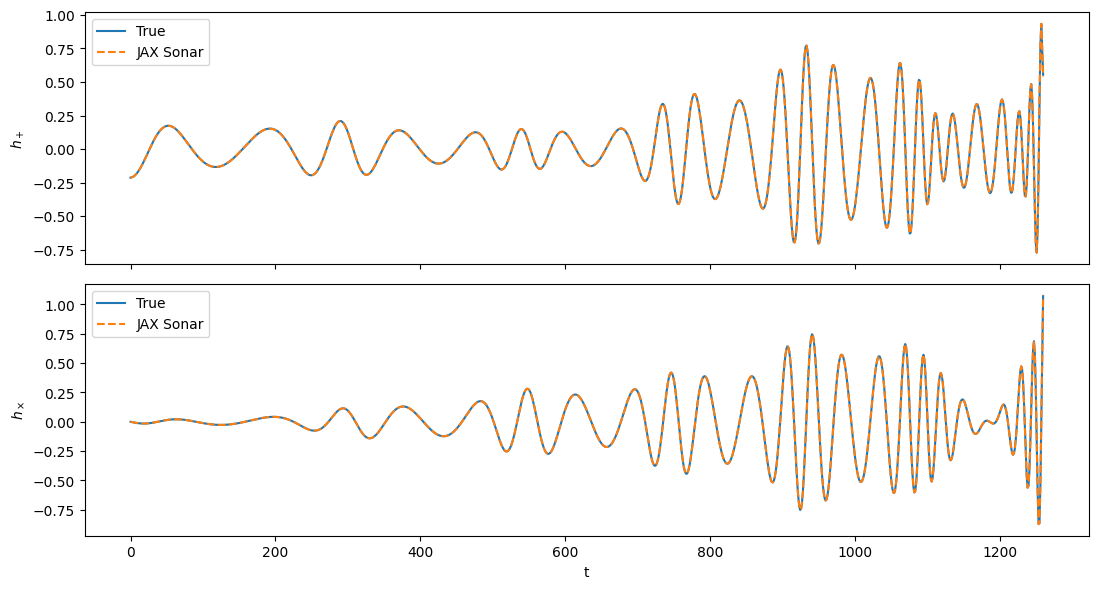

In [47]:
from jax import lax

(final_loss, (final_components, final_roots, final_shell, u0_fit)) = loss_only(
    params, t_full, hp_full, hc_full, LOSS_WEIGHTS
)
final_loss.block_until_ready()
print("final loss:", float(final_loss))
print("raw [waveform, Ricci, frequency, boundary]:", np.asarray(final_components))
print("mean horizon proxy:", float(jnp.mean(final_roots)))

errors = np.asarray(metric_errors_jit(params))
labels = ["g_tt", "g_rr", "g_thth", "g_phph", "g_tph"]
radii = [2, 3, 4, 5, 6, 12, 20]
print("\nMetric relative L2 error across theta (%)")
print("component", *[f"r={r}" for r in radii])
for label, row in zip(labels, errors):
    print(label, *[f"{x:.3f}" for x in row])

trajectory = jax.jit(integrate_network)(
    params["metric"], u0_fit, t_full
)
hp_pred, hc_pred = jax.vmap(
    lambda theta: create_gravityWave(t_full, trajectory, a_true, theta_obs=theta)
)(theta_observed.astype(t_full.dtype))

print("Recovered u0:", np.asarray(u0_fit))
print("True u0:", np.asarray(U0))
print("Mass shell:", float(final_shell))

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(np.asarray(t_full), np.asarray(hp_full[0]), label="True")
axes[0].plot(np.asarray(t_full), np.asarray(hp_pred[0]), "--", label="JAX Sonar")
axes[0].set_ylabel(r"$h_+$")
axes[0].legend()
axes[1].plot(np.asarray(t_full), np.asarray(hc_full[0]), label="True")
axes[1].plot(np.asarray(t_full), np.asarray(hc_pred[0]), "--", label="JAX Sonar")
axes[1].set_ylabel(r"$h_\times$")
axes[1].set_xlabel("t")
axes[1].legend()
plt.tight_layout()

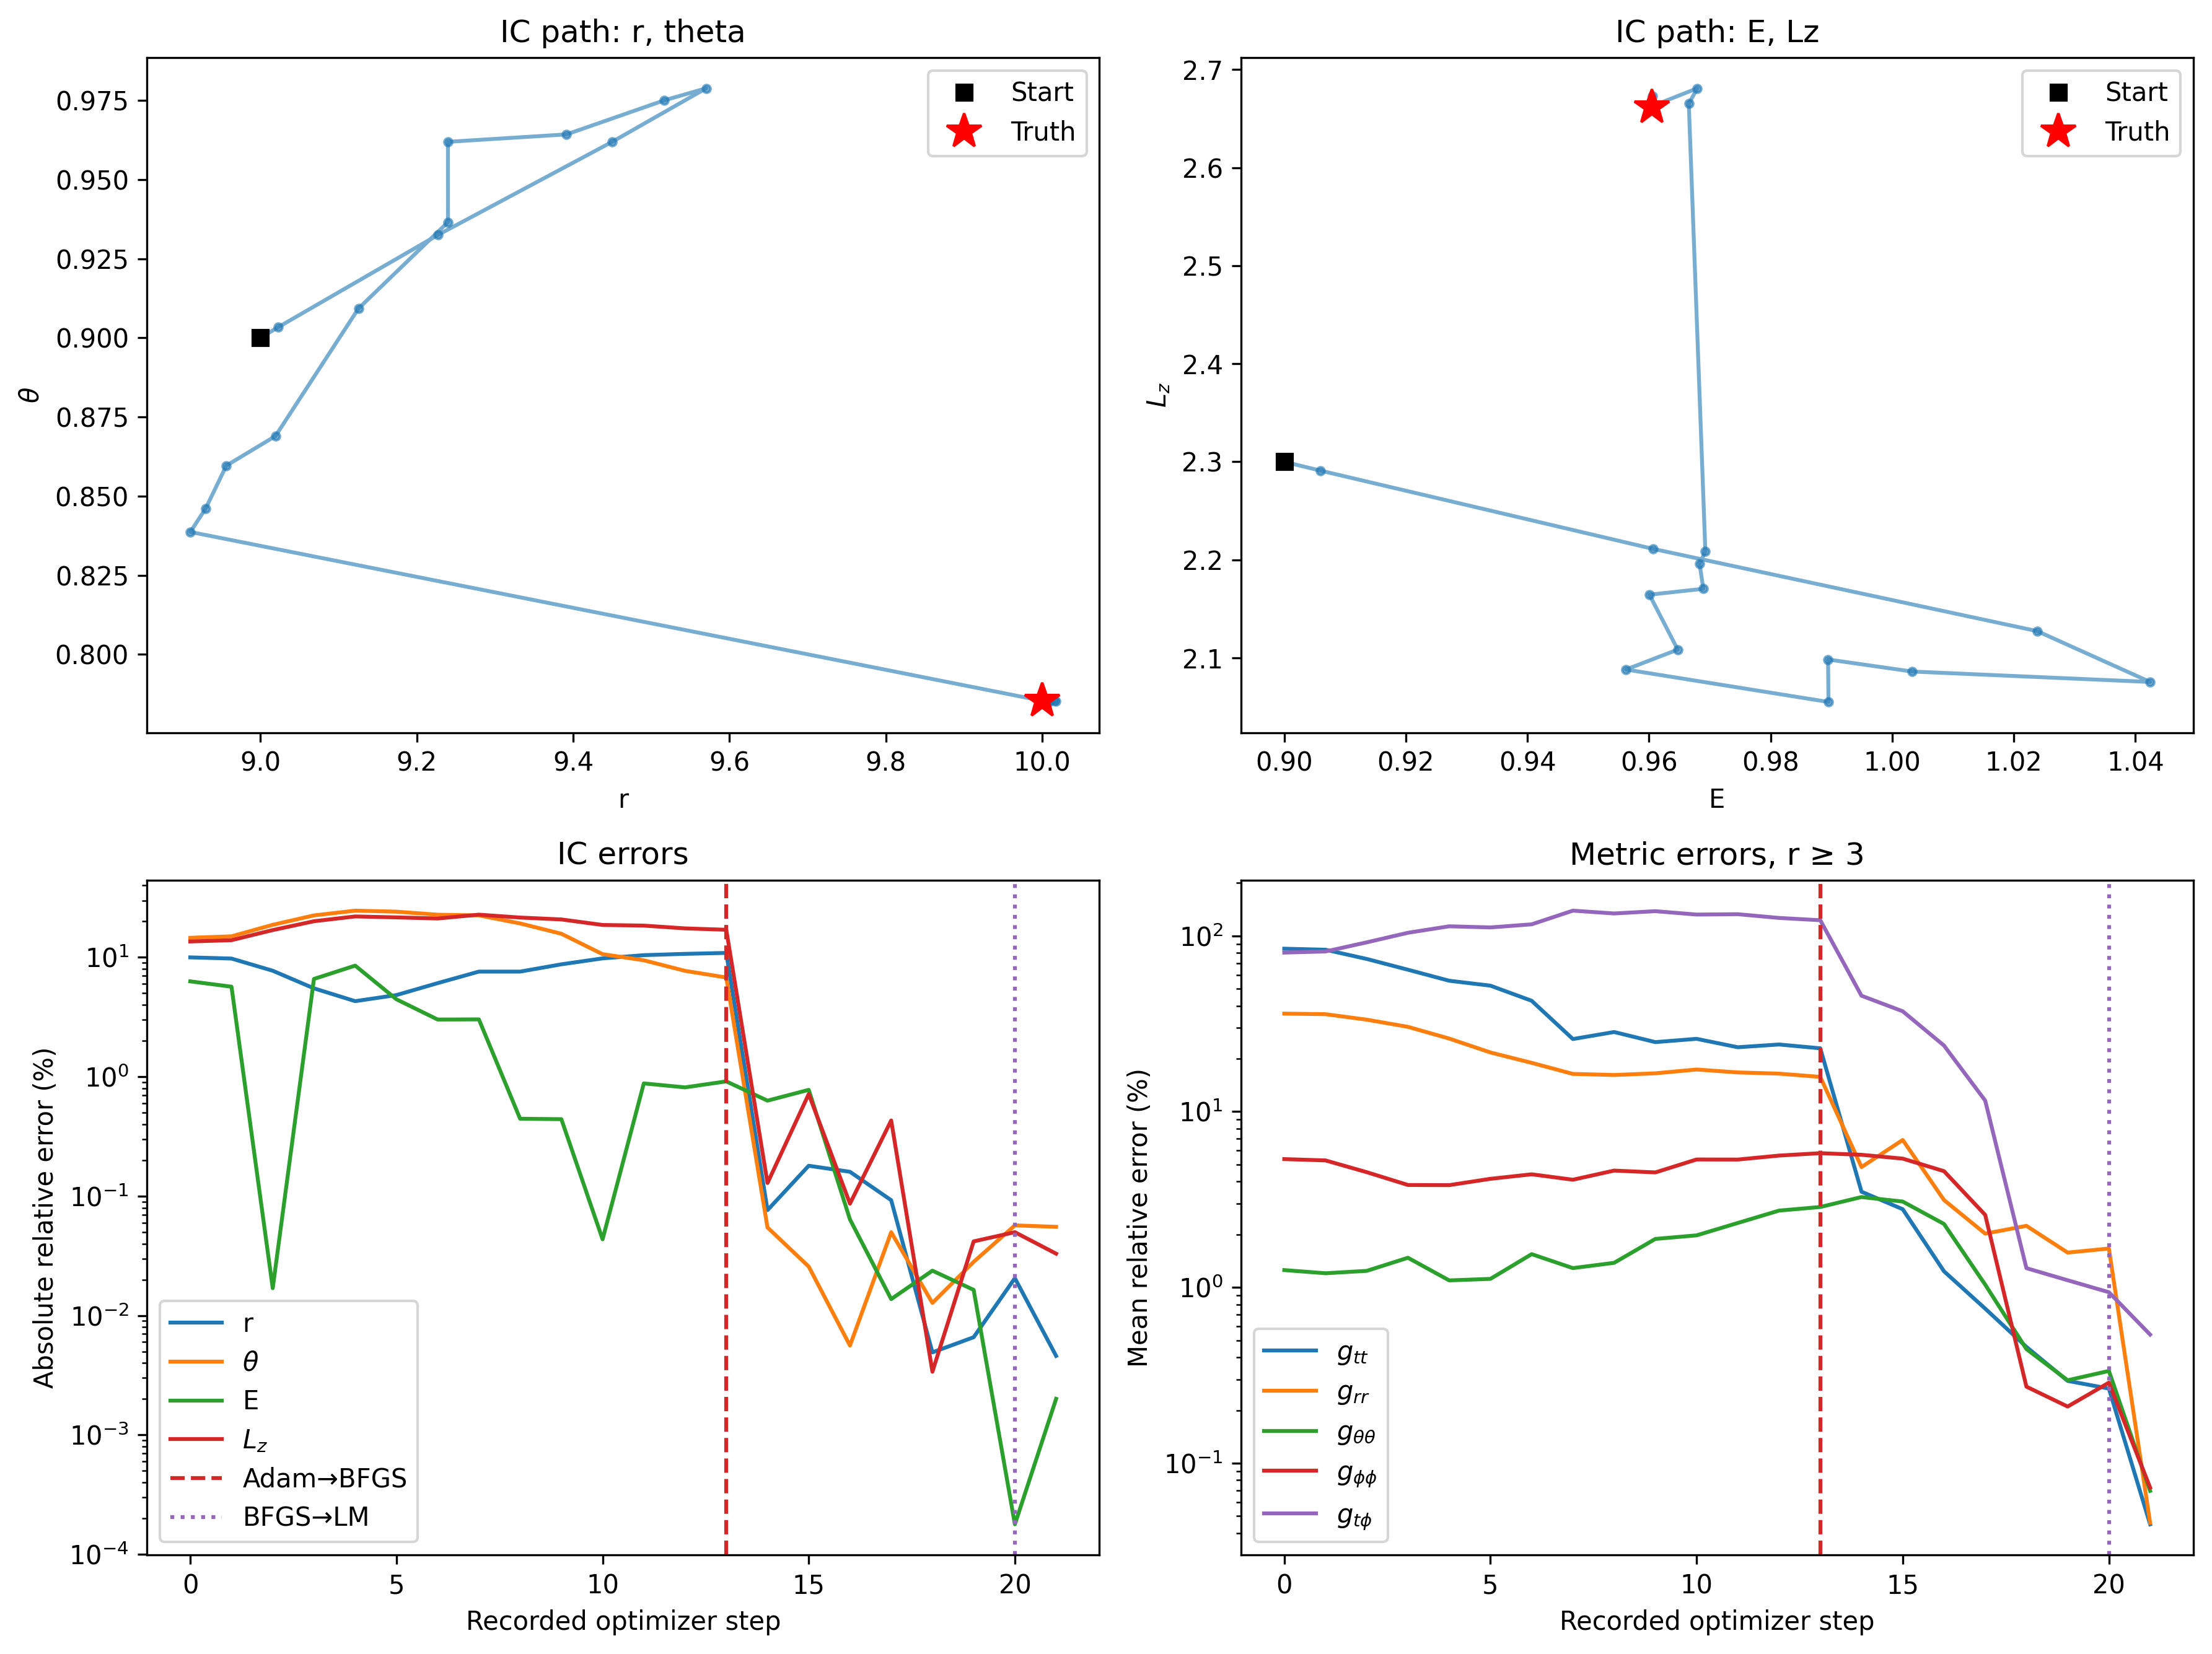

In [48]:
ic = np.asarray(histories["monitor_ic"])
metric = np.asarray(histories["monitor_metric"])
steps = np.arange(len(ic))

ic_true = np.asarray([
    U0[1],
    U0[2],
    -U0[4],
    U0[7],
], dtype=float)

ic_error = 100 * np.abs((ic - ic_true) / ic_true)
ic_error = np.maximum(ic_error, 1e-12)

metric_labels = [
    r"$g_{tt}$", r"$g_{rr}$", r"$g_{\theta\theta}$",
    r"$g_{\phi\phi}$", r"$g_{t\phi}$",
]

fig, ax = plt.subplots(2, 2, figsize=(12, 9), dpi = 300)

# r-theta path
ax[0, 0].plot(ic[:, 0], ic[:, 1], ".-", alpha=0.6)
ax[0, 0].plot(ic[0, 0], ic[0, 1], "ks", label="Start")
ax[0, 0].plot(ic_true[0], ic_true[1], "r*", ms=14, label="Truth")
ax[0, 0].set(xlabel="r", ylabel=r"$\theta$", title="IC path: r, theta")
ax[0, 0].legend()

# E-Lz path
ax[0, 1].plot(ic[:, 2], ic[:, 3], ".-", alpha=0.6)
ax[0, 1].plot(ic[0, 2], ic[0, 3], "ks", label="Start")
ax[0, 1].plot(ic_true[2], ic_true[3], "r*", ms=14, label="Truth")
ax[0, 1].set(xlabel="E", ylabel=r"$L_z$", title="IC path: E, Lz")
ax[0, 1].legend()

# IC errors
for i, label in enumerate(["r", r"$\theta$", "E", r"$L_z$"]):
    ax[1, 0].plot(steps, ic_error[:, i], label=label)

ax[1, 0].set_yscale("log")
ax[1, 0].set(
    xlabel="Recorded optimizer step",
    ylabel="Absolute relative error (%)",
    title="IC errors",
)
ax[1, 0].axvline(adam_monitor_end - 1, color="tab:red", ls="--", label="Adam→BFGS")
ax[1, 0].axvline(bfgs_monitor_end - 1, color="tab:purple", ls=":", label="BFGS→LM")
ax[1, 0].legend()

# Metric errors
for i, label in enumerate(metric_labels):
    ax[1, 1].plot(steps, metric[:, i], label=label)

ax[1, 1].set_yscale("log")
ax[1, 1].set(
    xlabel="Recorded optimizer step",
    ylabel="Mean relative error (%)",
    title="Metric errors, r ≥ 3",
)
ax[1, 1].axvline(adam_monitor_end - 1, color="tab:red", ls="--")
ax[1, 1].axvline(bfgs_monitor_end - 1, color="tab:purple", ls=":")
ax[1, 1].legend()

plt.tight_layout()

In [49]:
from types import SimpleNamespace

def report_weighted_gradient_geometry(joint):
    """Gradients of every weighted scalar loss term with respect to all 73 parameters."""
    x, unravel = ravel_pytree(joint)
    weights = LOSS_WEIGHTS.astype(x.dtype)

    def weighted_terms(x_flat):
        trial = unravel(x_flat)
        _, (components, _, shell, _) = loss(
            trial, t_full, hp_full, hc_full, weights
        )
        return jnp.concatenate((
            weights * components,
            jnp.asarray([P_MASS_SHELL * shell], dtype=x.dtype),
        ))

    values = jax.jit(weighted_terms)(x)
    gradients = jax.jit(jax.jacrev(weighted_terms))(x)
    values, gradients = jax.device_get((values, gradients))
    values = np.asarray(values)
    gradients = np.asarray(gradients)

    labels = ["waveform", "Ricci", "frequency", "boundary", "mass shell"]
    norms = np.linalg.norm(gradients, axis=1)
    cosine = gradients @ gradients.T / (
        norms[:, None] * norms[None, :] + 1e-300
    )

    print("Weighted loss and gradient norms")
    for label, value, norm in zip(labels, values, norms):
        print(f"{label:12s} loss={value:.6e}  |grad|={norm:.6e}")

    print("\nPairwise gradient cosines")
    print(" " * 13 + " ".join(f"{x[:5]:>8s}" for x in labels))
    for label, row in zip(labels, cosine):
        print(f"{label:12s} " + " ".join(f"{x:+8.4f}" for x in row))

    return {"labels": labels, "values": values, "gradients": gradients,
            "norms": norms, "cosine": cosine}


def report_lm_jacobian_geometry(lm_result, n_time=None, rank_rtol=1e-10):
    """Use the final LM Jacobian; no second expensive jacfwd call."""
    J = np.asarray(lm_result.jac, dtype=float)
    if n_time is None:
        n_time = hp_full.shape[1]

    n_wave = 2 * hp_full.shape[0] * n_time
    J_wave = J[:n_wave]

    # Derive column ownership from the pytree itself; do not assume dict order.
    marker = tree_util.tree_map(jnp.zeros_like, params)
    marker["ic"] = tree_util.tree_map(jnp.ones_like, params["ic"])
    ic_marker = np.asarray(jax.device_get(ravel_pytree(marker)[0]))
    ic_columns = np.flatnonzero(ic_marker != 0)
    metric_columns = np.flatnonzero(ic_marker == 0)
    J_ic = J_wave[:, ic_columns]
    J_metric = J_wave[:, metric_columns]

    def column_basis(A):
        U, s, _ = np.linalg.svd(A, full_matrices=False)
        rank = int(np.sum(s > rank_rtol * s[0])) if s.size and s[0] > 0 else 0
        return U[:, :rank], s, rank

    Q_ic, s_ic, rank_ic = column_basis(J_ic)
    Q_metric, s_metric, rank_metric = column_basis(J_metric)

    if rank_ic and rank_metric:
        cosines = np.linalg.svd(Q_ic.T @ Q_metric, compute_uv=False)
        angles = np.degrees(np.arccos(np.clip(cosines, 0.0, 1.0)))
        projection = Q_metric @ (Q_metric.T @ J_ic)
        explained = np.linalg.norm(projection) / (np.linalg.norm(J_ic) + 1e-300)
    else:
        angles = np.asarray([])
        explained = float("nan")

    s_full = np.linalg.svd(J, compute_uv=False)
    condition = s_full[0] / s_full[-1] if s_full[-1] > 0 else np.inf

    print("Full residual Jacobian:", J.shape)
    print("Waveform block:", J_wave.shape)
    print("Numerical ranks: IC=", rank_ic, "metric=", rank_metric)
    print("IC–metric principal angles (deg):", angles)
    print("Fraction of IC waveform sensitivity inside metric span:", explained)
    print("Full Jacobian condition number:", condition)
    print("Smallest/full largest singular ratio:", s_full[-1] / s_full[0])

    return {"J": J, "J_wave": J_wave, "angles_deg": angles,
            "ic_explained_fraction": explained, "singular_values": s_full,
            "condition": condition, "rank_ic": rank_ic,
            "rank_metric": rank_metric}

flat_loaded, unravel_loaded = ravel_pytree(params)

def residual_at_loaded(x):
    return full_residual_vector(
        unravel_loaded(x),
        t_full, hp_full, hc_full, LOSS_WEIGHTS,
    )

J_loaded = jax.jit(jax.jacfwd(residual_at_loaded))(flat_loaded)
J_loaded.block_until_ready()
lm_result = SimpleNamespace(
    jac=np.asarray(jax.device_get(J_loaded))
)

jacobian_geometry = report_lm_jacobian_geometry(lm_result)
gradient_geometry = report_weighted_gradient_geometry(params)

Full residual Jacobian: (4549, 73)
Waveform block: (2000, 73)
Numerical ranks: IC= 4 metric= 58
IC–metric principal angles (deg): [2.08304481e-03 4.51678796e-02 1.71909835e+00 6.58762823e+00]
Fraction of IC waveform sensitivity inside metric span: 0.9999999133044488
Full Jacobian condition number: 49175387966364.46
Smallest/full largest singular ratio: 2.0335375913739437e-14
Weighted loss and gradient norms
waveform     loss=1.323671e-05  |grad|=1.170342e+01
Ricci        loss=8.377138e-07  |grad|=2.305009e-04
frequency    loss=1.194527e-07  |grad|=3.734000e-03
boundary     loss=4.996722e-10  |grad|=4.042912e-05
mass shell   loss=4.400179e-11  |grad|=7.464654e-05

Pairwise gradient cosines
                wavef    Ricci    frequ    bound    mass 
waveform      +1.0000  +0.0313  +0.7732  -0.0098  -0.6752
Ricci         +0.0313  +1.0000  +0.2341  +0.1788  -0.0082
frequency     +0.7732  +0.2341  +1.0000  +0.0845  -0.2712
boundary      -0.0098  +0.1788  +0.0845  +1.0000  +0.0178
mass shell  

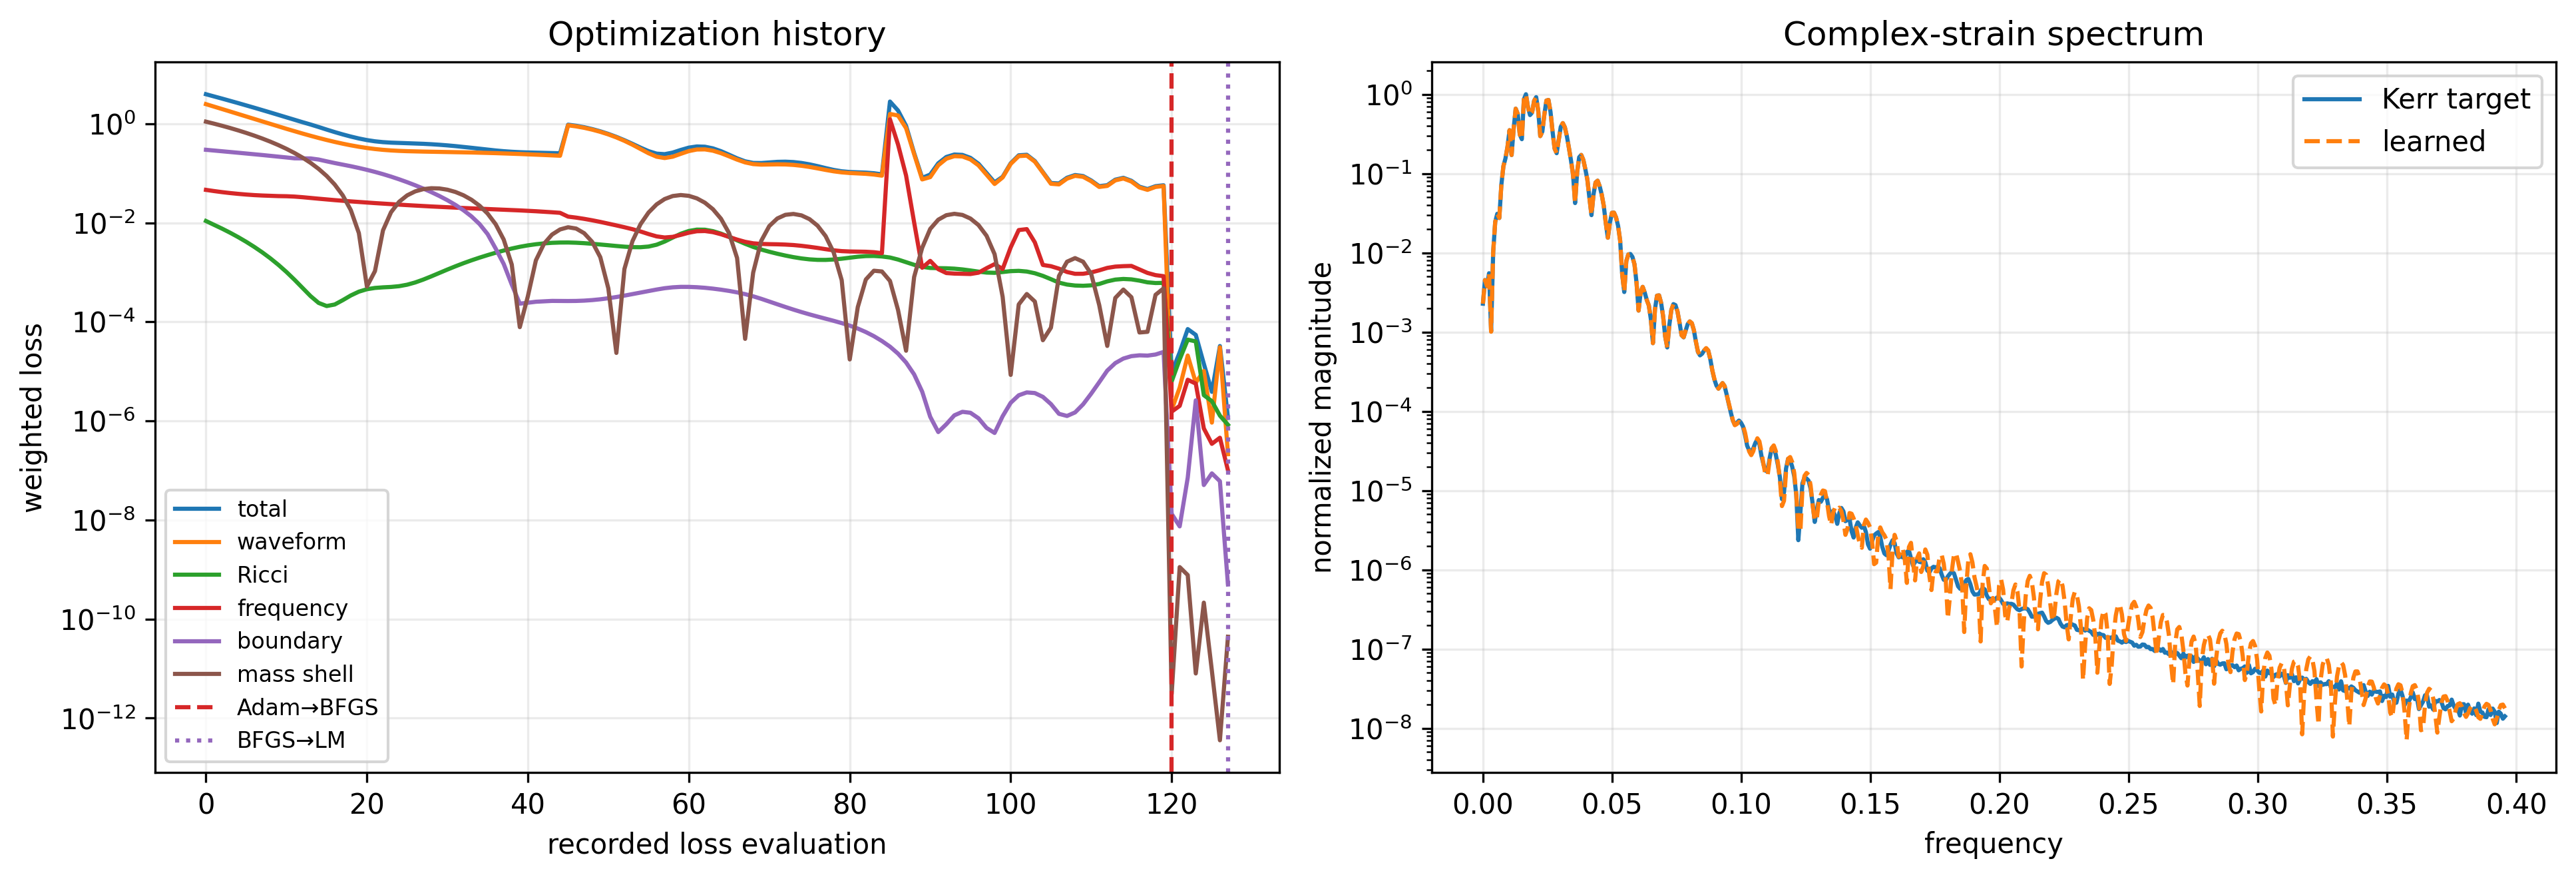

In [57]:
def plot_training_and_spectrum():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), dpi=300)

    for key, label in [
        ("total", "total"),
        ("waveform", "waveform"),
        ("ricci", "Ricci"),
        ("frequency", "frequency"),
        ("boundary", "boundary"),
        ("mass_shell", "mass shell"),
    ]:
        values = np.asarray(histories[key], dtype=float)
        axes[0].semilogy(np.maximum(values, 1e-30), label=label)

    axes[0].axvline(adam_history_end, color="tab:red", ls="--", label="Adam→BFGS")
    axes[0].axvline(bfgs_history_end, color="tab:purple", ls=":", label="BFGS→LM")
    axes[0].set(xlabel="recorded loss evaluation", ylabel="weighted loss",
                title="Optimization history")
    axes[0].grid(alpha=0.25)
    axes[0].legend(fontsize=8)

    dt = float(t_full[1] - t_full[0])
    h_true = np.asarray(hp_full[0] + 1j * hc_full[0])
    h_learned = np.asarray(hp_pred[0] + 1j * hc_pred[0])
    window = np.hanning(h_true.size)
    freq = np.fft.fftfreq(h_true.size, d=dt)
    positive = freq >= 0
    true_mag = np.abs(np.fft.fft(window * h_true))
    learned_mag = np.abs(np.fft.fft(window * h_learned))
    normalization = max(true_mag.max(), 1e-300)

    axes[1].semilogy(freq[positive], true_mag[positive] / normalization,
                     label="Kerr target")
    axes[1].semilogy(freq[positive], learned_mag[positive] / normalization,
                     "--", label="learned")
    axes[1].set(xlabel="frequency", ylabel="normalized magnitude",
                title="Complex-strain spectrum")
    axes[1].grid(alpha=0.25)
    axes[1].legend()
    fig.tight_layout()
    return fig


training_spectrum_figure = plot_training_and_spectrum()


True Kerr r_+: 1.4358898943540672
Soft-root estimator on exact Kerr: [1.43564665 1.43578763 1.43601218 1.43609606] mean= 1.4358856279547627
Soft roots on learned metric: [1.46723491 1.46728736 1.4671952  1.46715937] mean= 1.4672192106785713

Hard-root and rotation diagnostics
theta       r_H          omega_H      chi2(Omega_Kerr)   roots
 0.15708   1.46740359   0.31544672     -4.409265e-03  1
 0.78540   1.46702326   0.30942664     -1.793003e-03  1
 1.04720   1.46708610   0.30564581     -8.362856e-04  1
 1.57080   1.46700803   0.30185810     -2.049809e-04  1
Hard-root mean: 1.46713024261375 relative error (%): 2.175678537924123

Far-field frame dragging
r      theta      omega error (%)    J_eff error (%)
   4    0.78540         0.719842         0.815782
   4    1.04720         0.575573         0.685388
   4    1.57080         0.483021         0.609542
  10    0.78540         0.084563         0.092282
  10    1.04720         0.085779         0.088570
  10    1.57080         0.082387    

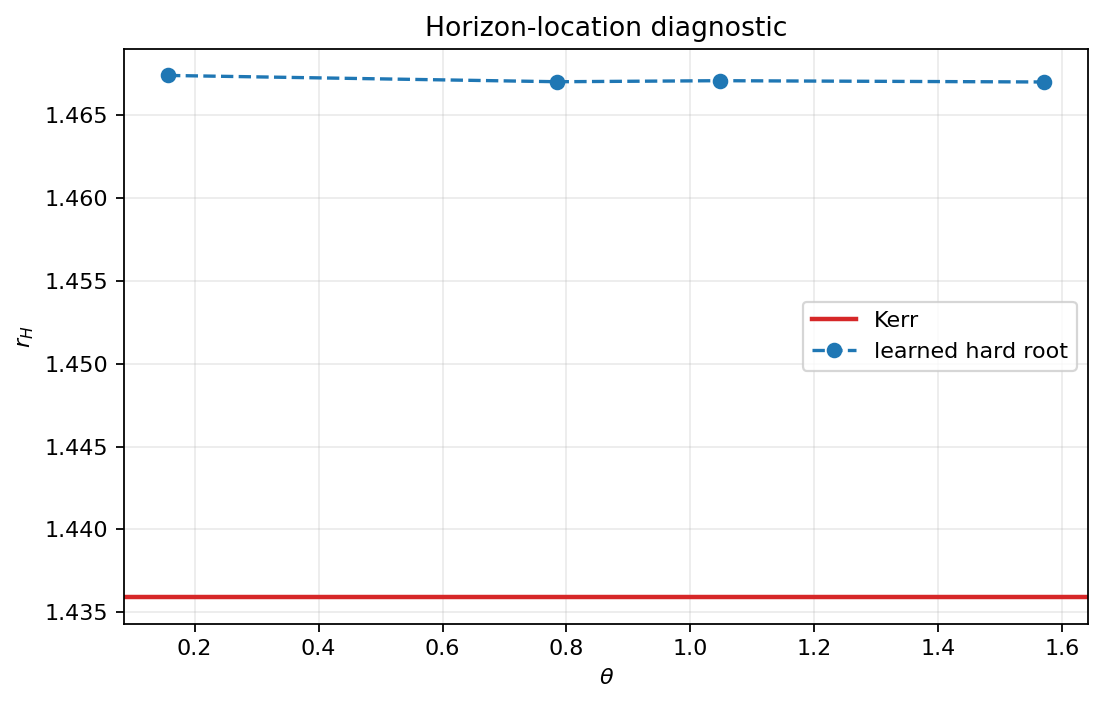

In [51]:
def horizon_and_rotation_diagnostics(joint, n_r=801):
    metric_params = joint["metric"]
    r_plus = 1.0 + math.sqrt(1.0 - a_true**2)
    omega_true = a_true / (2.0 * r_plus)
    theta_values = np.asarray([math.pi/20, math.pi/4, math.pi/3, math.pi/2])
    radial_grid = np.linspace(1.0, 2.01, n_r)

    def learned_metric(r, theta):
        return np.asarray(jax.device_get(metric_from_network(
            metric_params, jnp.asarray(r, dtype=jnp.float64),
            jnp.asarray(theta, dtype=jnp.float64)
        )), dtype=float)

    def kerr_metric(r, theta):
        return np.asarray(jax.device_get(g_Kerr(
            jnp.asarray(r, dtype=jnp.float64),
            jnp.asarray(theta, dtype=jnp.float64)
        )), dtype=float)

    def qrr(metric_function, r, theta):
        return 1.0 / metric_function(r, theta)[1, 1]

    def all_roots(metric_function, theta):
        values = np.asarray([qrr(metric_function, r, theta) for r in radial_grid])
        roots = []
        for i in range(radial_grid.size - 1):
            y0, y1 = values[i], values[i + 1]
            if not (np.isfinite(y0) and np.isfinite(y1)):
                continue
            if y0 == 0.0:
                roots.append(float(radial_grid[i]))
            elif y0 * y1 < 0.0:
                roots.append(optimize.brentq(
                    lambda radius: qrr(metric_function, radius, theta),
                    radial_grid[i], radial_grid[i + 1], xtol=1e-12
                ))
        return np.asarray(sorted(set(np.round(roots, 12))), dtype=float)

    def soft_roots(metric_function, tau=1e-4):
        out = []
        r_values = np.asarray(BC_R, dtype=float)
        for theta in np.asarray(BC_THETA, dtype=float):
            q = np.asarray([qrr(metric_function, r, theta) for r in r_values])
            logits = -(q*q) / tau
            logits -= logits.max()
            w = np.exp(logits)
            w /= w.sum()
            out.append(np.sum(w * r_values))
        return np.asarray(out)

    learned_soft = soft_roots(learned_metric)
    kerr_soft = soft_roots(kerr_metric)
    learned_hard = []

    print("True Kerr r_+:", r_plus)
    print("Soft-root estimator on exact Kerr:", kerr_soft,
          "mean=", kerr_soft.mean())
    print("Soft roots on learned metric:", learned_soft,
          "mean=", learned_soft.mean())
    print("\nHard-root and rotation diagnostics")
    print("theta       r_H          omega_H      chi2(Omega_Kerr)   roots")

    for theta in theta_values:
        roots = all_roots(learned_metric, theta)
        root = roots[-1] if roots.size else np.nan
        learned_hard.append(root)
        if np.isfinite(root):
            g = learned_metric(root, theta)
            omega = -g[0, 3] / g[3, 3]
            chi2 = g[0, 0] + 2*omega_true*g[0, 3] + omega_true**2*g[3, 3]
            print(f"{theta:8.5f}  {root:11.8f}  {omega:11.8f}  {chi2:+16.6e}  {roots.size}")
        else:
            print(f"{theta:8.5f}  no root")

    learned_hard = np.asarray(learned_hard)
    finite = np.isfinite(learned_hard)
    if finite.any():
        hard_mean = learned_hard[finite].mean()
        print("Hard-root mean:", hard_mean,
              "relative error (%):", 100*(hard_mean-r_plus)/r_plus)

    print("\nFar-field frame dragging")
    print("r      theta      omega error (%)    J_eff error (%)")
    for radius in (4.0, 10.0, 14.0, 20.0):
        for theta in (math.pi/4, math.pi/3, math.pi/2):
            gn = learned_metric(radius, theta)
            gt = kerr_metric(radius, theta)
            omega_n = -gn[0, 3] / gn[3, 3]
            omega_t = -gt[0, 3] / gt[3, 3]
            jeff_n = -radius * gn[0, 3] / (2*math.sin(theta)**2)
            jeff_t = -radius * gt[0, 3] / (2*math.sin(theta)**2)
            print(f"{radius:4.0f}  {theta:9.5f}  "
                  f"{100*abs(omega_n-omega_t)/(abs(omega_t)+1e-300):15.6f}  "
                  f"{100*abs(jeff_n-jeff_t)/(abs(jeff_t)+1e-300):15.6f}")

    # Exterior signature/determinant check, off the horizon coordinate singularity.
    bad_signature = 0
    nonfinite = 0
    min_abs_det = np.inf
    for radius in np.linspace(2.05, 20.0, 25):
        for theta in np.linspace(math.pi/20, math.pi/2, 9):
            g = learned_metric(radius, theta)
            eig = np.linalg.eigvalsh(g)
            det = np.linalg.det(g)
            if not np.isfinite(g).all() or not np.isfinite(det):
                nonfinite += 1
                continue
            bad_signature += int(np.sum(eig < 0) != 1)
            min_abs_det = min(min_abs_det, abs(det))
    print("\nExterior nonfinite metrics:", nonfinite)
    print("Exterior non-Lorentzian points:", bad_signature)
    print("Minimum |det(g)| on exterior validation grid:", min_abs_det)

    fig, ax = plt.subplots(figsize=(7, 4.5), dpi=160)
    ax.axhline(r_plus, color="tab:red", lw=2, label="Kerr")
    ax.plot(theta_values[finite], learned_hard[finite], "o--", label="learned hard root")
    ax.set(xlabel=r"$\theta$", ylabel=r"$r_H$", title="Horizon-location diagnostic")
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()

    return {"r_plus": r_plus, "omega_true": omega_true,
            "kerr_soft": kerr_soft, "learned_soft": learned_soft,
            "theta": theta_values, "learned_hard": learned_hard}


horizon_diagnostics = horizon_and_rotation_diagnostics(params)


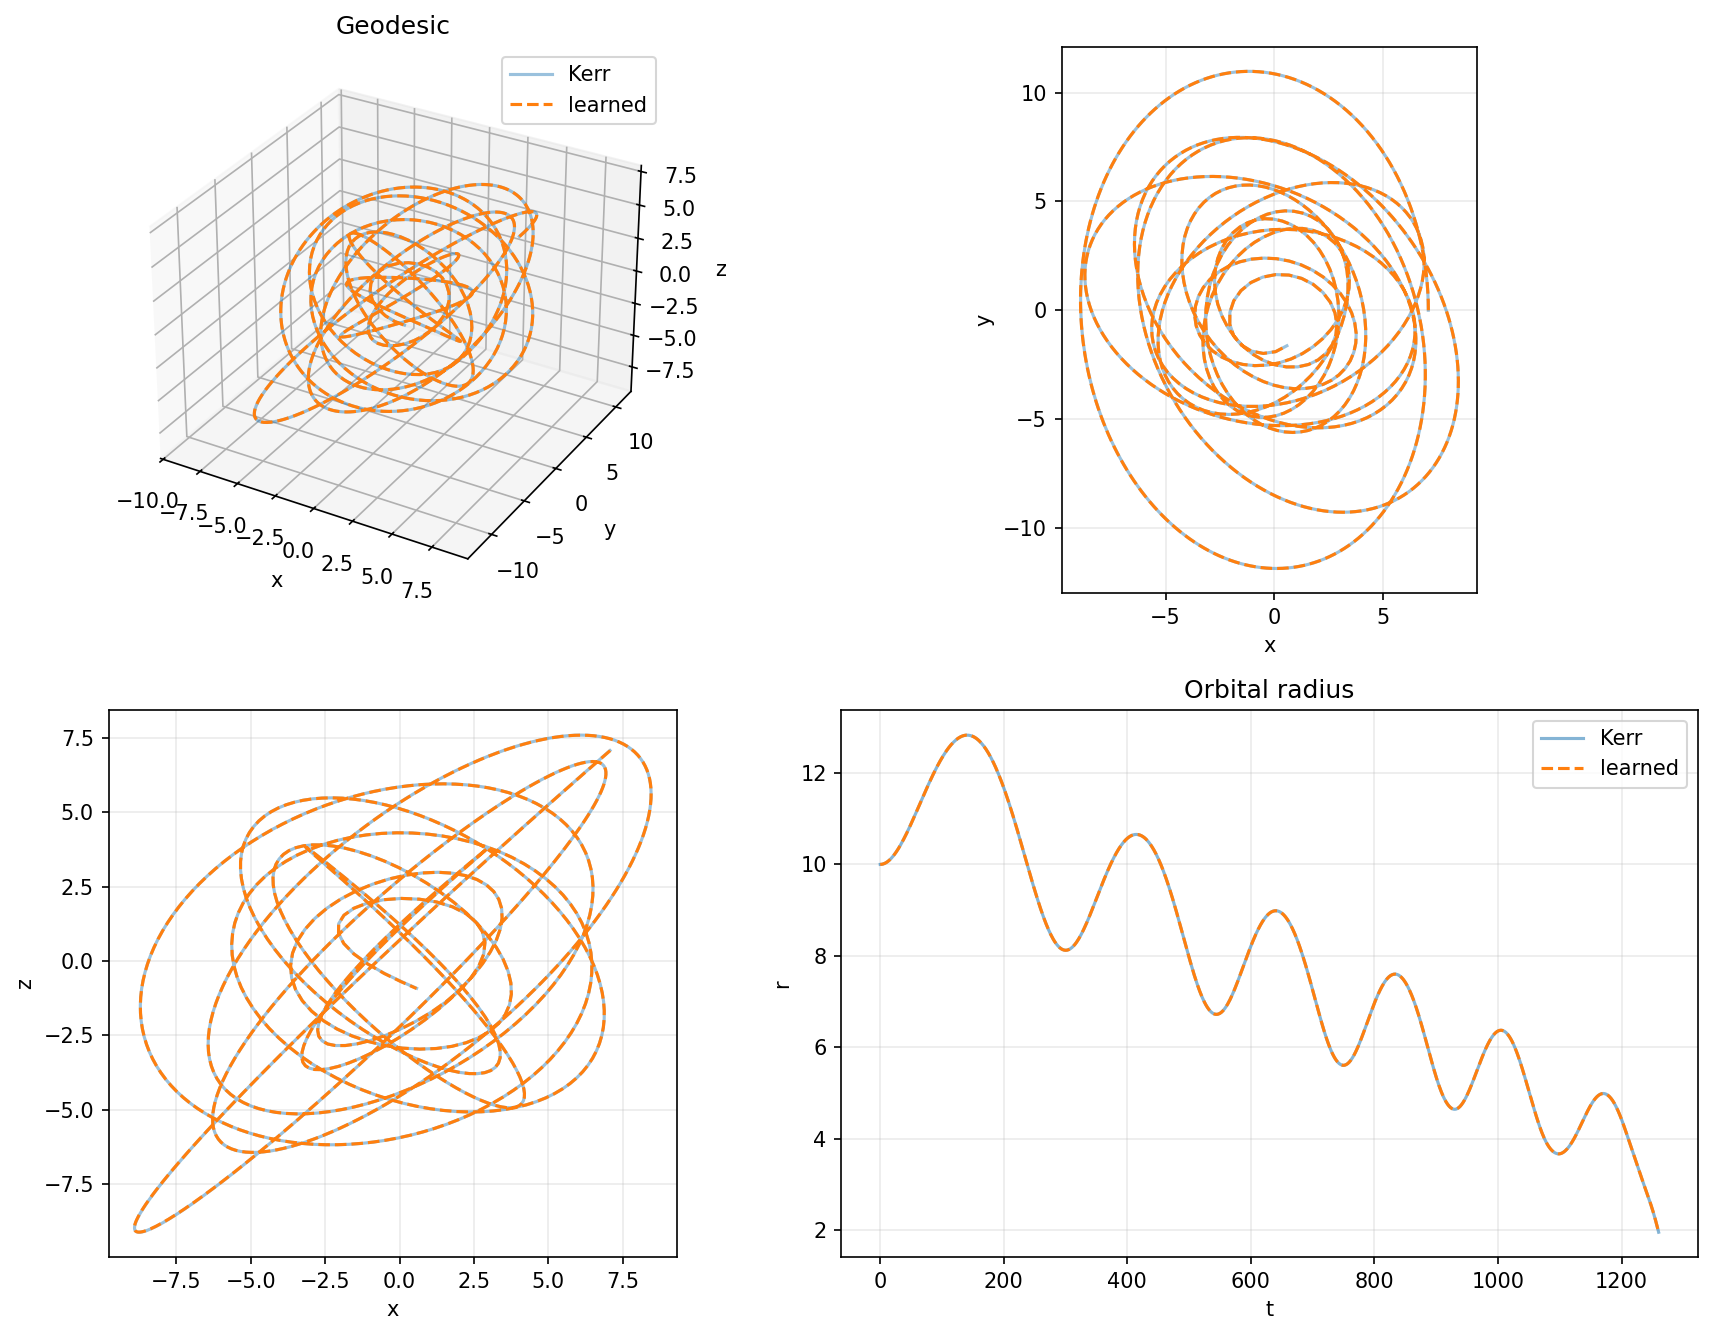

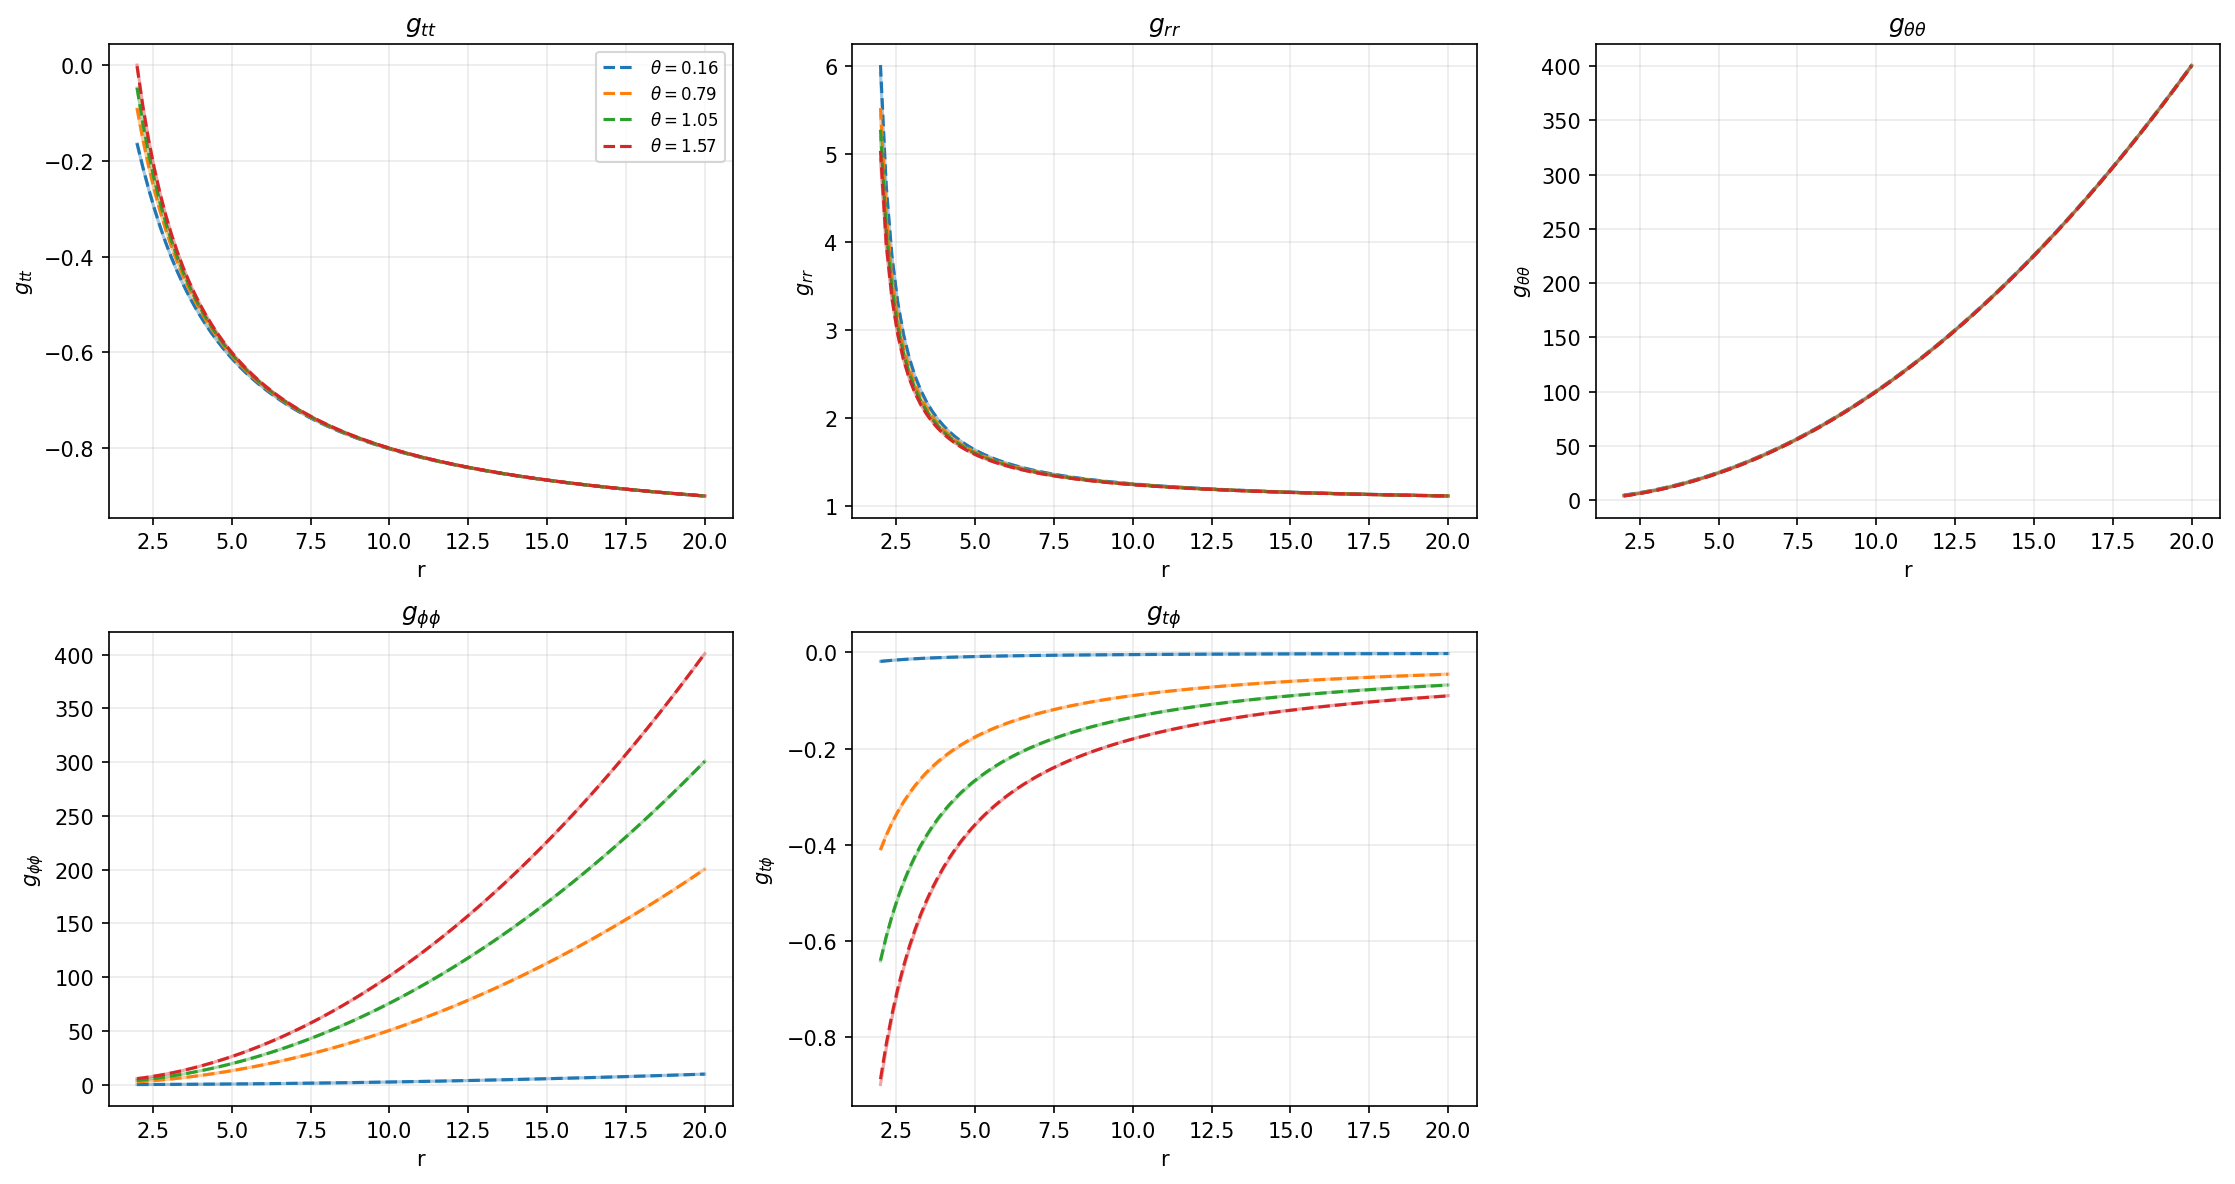

In [52]:
def plot_orbit_radius_and_metric_profiles(joint, trajectory_true, trajectory_learned):
    true_orbit = np.asarray(jax.device_get(Soln2Orbit(trajectory_true, a_true)))
    learned_orbit = np.asarray(jax.device_get(Soln2Orbit(trajectory_learned, a_true)))
    time_values = np.asarray(jax.device_get(t_full))
    true_traj = np.asarray(jax.device_get(trajectory_true))
    learned_traj = np.asarray(jax.device_get(trajectory_learned))

    fig = plt.figure(figsize=(12, 9), dpi=150)
    ax = fig.add_subplot(221, projection="3d")
    ax.plot(*true_orbit, alpha=0.45, label="Kerr")
    ax.plot(*learned_orbit, "--", label="learned")
    ax.set(xlabel="x", ylabel="y", zlabel="z", title="Geodesic")
    ax.legend()

    for position, i, j, labels in [
        (222, 0, 1, ("x", "y")),
        (223, 0, 2, ("x", "z")),
    ]:
        ax = fig.add_subplot(position)
        ax.plot(true_orbit[i], true_orbit[j], alpha=0.45, label="Kerr")
        ax.plot(learned_orbit[i], learned_orbit[j], "--", label="learned")
        ax.set(xlabel=labels[0], ylabel=labels[1])
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.25)

    ax = fig.add_subplot(224)
    ax.plot(time_values, true_traj[:, 1], alpha=0.55, label="Kerr")
    ax.plot(time_values, learned_traj[:, 1], "--", label="learned")
    ax.set(xlabel="t", ylabel="r", title="Orbital radius")
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()

    indices = [(0, 0), (1, 1), (2, 2), (3, 3), (0, 3)]
    labels = [r"$g_{tt}$", r"$g_{rr}$", r"$g_{\theta\theta}$",
              r"$g_{\phi\phi}$", r"$g_{t\phi}$"]
    radii = np.linspace(2.0, 20.0, 100)
    thetas = [math.pi/20, math.pi/4, math.pi/3, math.pi/2]
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

    fig_metric, axes = plt.subplots(2, 3, figsize=(15, 8), dpi=150)
    for ax, index, label in zip(axes.flat, indices, labels):
        for theta, color in zip(thetas, colors):
            pred = np.asarray([
                metric_from_network(joint["metric"], r, theta)[index]
                for r in radii
            ], dtype=float)
            true = np.asarray([g_Kerr(r, theta)[index] for r in radii], dtype=float)
            ax.plot(radii, true, color=color, alpha=0.40)
            ax.plot(radii, pred, "--", color=color,
                    label=rf"$\theta={theta:.2f}$")
        ax.set(xlabel="r", ylabel=label, title=label)
        ax.grid(alpha=0.25)
    axes.flat[0].legend(fontsize=8)
    axes.flat[-1].axis("off")
    fig_metric.tight_layout()
    return fig, fig_metric


orbit_figure, metric_profile_figure = plot_orbit_radius_and_metric_profiles(
    params, trajectory_gate, trajectory
)


In [53]:
"""Paste-ready JAX/NumPy diagnostic plots for Best_Run_Test_Revised.ipynb.

This cell assumes the notebook has already created:
    params, trajectory_gate, trajectory, t_full,
    metric_from_network, g_Kerr, network_apply, nn_input,
    a_true, and ra_true.

No PyTorch objects are used.
"""

import math
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Circle
from scipy.optimize import brentq


# -----------------------------------------------------------------------------
# Shared style and conversion helpers
# -----------------------------------------------------------------------------

THETA_COLORS = ["#0072B2", "#B25E00", "#00806A", "#C0392B"]

TRUE_COLOR = "#D62728"
PRED_COLOR = "#0072B2"
SPIN_COLOR = "#D62728"
BH_COLOR = "#0B0B0B"
ERGO_COLOR = "#7A5C9E"

TRUE_KW = dict(
    color=TRUE_COLOR,
    lw=1.7,
    alpha=0.42,
    solid_capstyle="round",
    zorder=2,
)
PRED_KW = dict(
    color=PRED_COLOR,
    lw=1.6,
    ls=(0, (5, 2.5)),
    zorder=3,
)

# The casing must be wider than the predicted curve or it is invisible.
CASING = [pe.Stroke(linewidth=3.4, foreground="white"), pe.Normal()]

_COMPONENTS = [
    r"g_{tt}",
    r"g_{rr}",
    r"g_{\theta\theta}",
    r"g_{\phi\phi}",
    r"g_{t\phi}",
]
_INDEX = [(0, 0), (1, 1), (2, 2), (3, 3), (0, 3)]


def _to_numpy(value, dtype=float):
    """Convert a JAX/NumPy value to a host NumPy array."""
    return np.asarray(jax.device_get(value), dtype=dtype)


def _metric_params(joint_or_metric):
    """Accept either the joint {'metric', 'ic'} tree or the metric subtree."""
    if isinstance(joint_or_metric, dict) and "metric" in joint_or_metric:
        return joint_or_metric["metric"]
    return joint_or_metric


def _grid(ax):
    ax.grid(True, lw=0.45, alpha=0.25, zorder=0)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)


def _r_plus(a, M=1.0):
    return M + math.sqrt(max(M * M - a * a, 0.0))


def _r_ergo(theta, a, M=1.0):
    """Outer Kerr static-limit radius, not a constant except at the equator."""
    theta = np.asarray(theta)
    return M + np.sqrt(np.maximum(M * M - (a * np.cos(theta)) ** 2, 0.0))


def _orbit_cartesian(solution):
    """Notebook's spherical Boyer-Lindquist-to-Cartesian display map."""
    solution = _to_numpy(solution)
    r = solution[:, 1]
    theta = solution[:, 2]
    phi = solution[:, 3]
    return np.stack(
        (
            r * np.sin(theta) * np.cos(phi),
            r * np.sin(theta) * np.sin(phi),
            r * np.cos(theta),
        )
    )


def _add_black_hole_3d(ax, a, M=1.0, arrow_scale=2.0, show_ergo=False):
    """Coordinate horizon sphere, optional static-limit surface, spin arrow."""
    r_plus = _r_plus(a, M)
    phi = np.linspace(0.0, 2.0 * np.pi, 72)
    theta = np.linspace(0.0, np.pi, 48)
    PHI, THETA = np.meshgrid(phi, theta)

    if show_ergo:
        r_ergo = _r_ergo(THETA, a, M)
        ax.plot_surface(
            r_ergo * np.sin(THETA) * np.cos(PHI),
            r_ergo * np.sin(THETA) * np.sin(PHI),
            r_ergo * np.cos(THETA),
            color=ERGO_COLOR,
            alpha=0.12,
            shade=False,
            linewidth=0,
            antialiased=True,
            zorder=0,
        )

    ax.plot_surface(
        r_plus * np.sin(THETA) * np.cos(PHI),
        r_plus * np.sin(THETA) * np.sin(PHI),
        r_plus * np.cos(THETA),
        color=BH_COLOR,
        shade=True,
        linewidth=0,
        antialiased=True,
        zorder=1,
    )

    arrow_length = arrow_scale * 3.2 * r_plus
    ax.quiver(
        0,
        0,
        0,
        0,
        0,
        arrow_length,
        color=SPIN_COLOR,
        lw=2.0,
        arrow_length_ratio=0.22,
        zorder=10,
    )


def _add_black_hole_2d(
    ax,
    a,
    M=1.0,
    plane="xy",
    spin_arrow=False,
    arrow_len=None,
    show_ergo=False,
):
    """Coordinate horizon and the appropriate 2D static-limit cross-section."""
    r_plus = _r_plus(a, M)

    if show_ergo:
        if plane == "xy":
            ax.add_patch(
                Circle(
                    (0, 0),
                    2.0 * M,
                    facecolor=ERGO_COLOR,
                    edgecolor=ERGO_COLOR,
                    alpha=0.10,
                    lw=1.0,
                    zorder=0,
                )
            )
        else:
            theta = np.linspace(0.0, np.pi, 400)
            r_static = _r_ergo(theta, a, M)
            rho = r_static * np.sin(theta)
            z = r_static * np.cos(theta)
            ax.plot(rho, z, color=ERGO_COLOR, lw=1.0, alpha=0.65, zorder=1)
            ax.plot(-rho, z, color=ERGO_COLOR, lw=1.0, alpha=0.65, zorder=1)

    ax.add_patch(
        Circle((0, 0), r_plus, facecolor=BH_COLOR, edgecolor="none", zorder=4)
    )

    if spin_arrow:
        length = arrow_len if arrow_len is not None else 3.0 * r_plus
        ax.annotate(
            "",
            xy=(0, length),
            xytext=(0, 0),
            zorder=6,
            arrowprops=dict(arrowstyle="-|>", color=SPIN_COLOR, lw=1.8),
        )


# -----------------------------------------------------------------------------
# 1. Geodesic projections
# -----------------------------------------------------------------------------

def plotGeodesicProjections(
    soln_true,
    soln_pred,
    a_spin,
    show_ergo=False,
    lim=None,
):
    """Kerr and learned geodesics in 3D plus all Cartesian projections."""
    true_xyz = _orbit_cartesian(soln_true)
    pred_xyz = _orbit_cartesian(soln_pred)

    if lim is None:
        lim = 1.05 * max(
            np.nanmax(np.abs(true_xyz)),
            np.nanmax(np.abs(pred_xyz)),
            1.0,
        )

    fig = plt.figure(figsize=(13.5, 11), dpi=180)

    ax3d = fig.add_subplot(221, projection="3d")
    _add_black_hole_3d(ax3d, a_spin, show_ergo=show_ergo)
    ax3d.plot(*true_xyz, label="Kerr", **TRUE_KW)
    ax3d.plot(
        *pred_xyz,
        label="learned metric",
        path_effects=CASING,
        **PRED_KW,
    )
    ax3d.set_title("3D geodesic", pad=2)
    ax3d.set_xlabel("x / M")
    ax3d.set_ylabel("y / M")
    ax3d.set_zlabel("z / M")
    ax3d.set_xlim(-lim, lim)
    ax3d.set_ylim(-lim, lim)
    ax3d.set_zlim(-lim, lim)
    ax3d.view_init(elev=22, azim=-58)
    try:
        ax3d.set_box_aspect((1, 1, 1))
    except Exception:
        pass
    ax3d.legend(loc="upper left", frameon=False, fontsize=9)

    panels = [
        (222, 0, 1, "x", "y", "X–Y (precession)", "xy", False),
        (223, 0, 2, "x", "z", "X–Z (wobble)", "xz", True),
        (224, 1, 2, "y", "z", "Y–Z (inclination)", "yz", True),
    ]

    for position, i, j, xlabel, ylabel, title, plane, poloidal in panels:
        ax = fig.add_subplot(position)
        _grid(ax)
        _add_black_hole_2d(
            ax,
            a_spin,
            plane=plane,
            spin_arrow=poloidal,
            arrow_len=0.45 * lim,
            show_ergo=show_ergo,
        )
        ax.plot(true_xyz[i], true_xyz[j], **TRUE_KW)
        ax.plot(
            pred_xyz[i],
            pred_xyz[j],
            path_effects=CASING,
            **PRED_KW,
        )
        ax.set_title(title, pad=4)
        ax.set_xlabel(f"{xlabel} / M")
        ax.set_ylabel(f"{ylabel} / M")
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ax.set_aspect("equal", adjustable="box")

    fig.suptitle("Kerr vs learned-metric geodesic", y=0.985, fontsize=13)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    return fig


# -----------------------------------------------------------------------------
# 2. Orbital radius and residual
# -----------------------------------------------------------------------------

def plot_radius_overlay(t, traj_true, traj_pred, rp_horizon=None, a=None):
    """Overlay r(t), show the local Kerr static limit, and plot the residual."""
    if a is None:
        a = a_true

    time = _to_numpy(t)
    true_trajectory = _to_numpy(traj_true)
    pred_trajectory = _to_numpy(traj_pred)
    n = min(len(time), len(true_trajectory), len(pred_trajectory))
    time = time[:n]
    true_trajectory = true_trajectory[:n]
    pred_trajectory = pred_trajectory[:n]

    r_true = true_trajectory[:, 1]
    r_pred = pred_trajectory[:, 1]
    r_plus = _r_plus(a) if rp_horizon is None else float(rp_horizon)
    r_static = _r_ergo(true_trajectory[:, 2], a)

    relative_l2 = 100.0 * np.linalg.norm(r_pred - r_true) / (
        np.linalg.norm(r_true) + 1e-300
    )
    max_absolute = np.max(np.abs(r_pred - r_true))

    fig, (ax, ax_residual) = plt.subplots(
        2,
        1,
        figsize=(9.5, 6.5),
        dpi=180,
        sharex=True,
        gridspec_kw=dict(height_ratios=[3, 1], hspace=0.08),
    )

    ax.plot(time, r_true, label="Kerr", **TRUE_KW)
    ax.plot(
        time,
        r_pred,
        label="learned metric",
        path_effects=CASING,
        **PRED_KW,
    )
    ax.axhline(r_plus, color=BH_COLOR, lw=1.2, label=r"Kerr $r_+$")
    ax.axhspan(0.0, r_plus, color=BH_COLOR, alpha=0.08, lw=0)
    ax.plot(
        time,
        r_static,
        color=ERGO_COLOR,
        lw=1.0,
        ls=":",
        alpha=0.9,
        label=r"Kerr static limit $r_{\rm ergo}(\theta)$",
    )
    ax.fill_between(
        time,
        r_plus,
        r_static,
        where=r_static >= r_plus,
        color=ERGO_COLOR,
        alpha=0.06,
        lw=0,
    )
    _grid(ax)
    ax.set_ylabel(r"$r/M$")
    ax.set_ylim(bottom=0.0)
    ax.legend(frameon=True, loc="upper right", fontsize=8)
    ax.set_title(
        rf"Orbital radius: relative $L_2={relative_l2:.4f}\%$, "
        rf"$\max|\Delta r|={max_absolute:.3e}M$",
        pad=6,
    )

    residual = r_pred - r_true
    ax_residual.axhline(0.0, color="#555555", lw=1.0, alpha=0.7)
    ax_residual.plot(time, residual, color=PRED_COLOR, lw=1.3)
    ax_residual.fill_between(time, 0.0, residual, color=PRED_COLOR, alpha=0.14)
    _grid(ax_residual)
    ax_residual.set_xlabel(r"$t/M$")
    ax_residual.set_ylabel(r"$\Delta r/M$")
    fig.tight_layout()

    return fig, {
        "relative_l2_percent": relative_l2,
        "max_absolute_residual": max_absolute,
        "residual": residual,
    }


# -----------------------------------------------------------------------------
# 3. Compact metric-component figures
# -----------------------------------------------------------------------------

def _sample_metric_grid(joint, r_values, theta_values):
    """Return learned and Kerr metrics with shape (theta, r, 4, 4)."""
    metric_params = _metric_params(joint)
    dtype = metric_params["w1"].dtype
    radii = jnp.asarray(r_values, dtype=dtype)
    thetas = jnp.asarray(theta_values, dtype=dtype)

    learned = jax.vmap(
        lambda theta: jax.vmap(
            lambda radius: metric_from_network(metric_params, radius, theta)
        )(radii)
    )(thetas)
    kerr = jax.vmap(
        lambda theta: jax.vmap(lambda radius: g_Kerr(radius, theta))(radii)
    )(thetas)
    return _to_numpy(learned), _to_numpy(kerr)


def _component_arrays(metric_grid):
    """Convert (theta, r, 4, 4) metrics to (component, r, theta)."""
    return np.stack(
        [metric_grid[:, :, i, j].T for i, j in _INDEX],
        axis=0,
    )


def _metric_figure_legend(theta_values, include_equator=True):
    start = 0 if include_equator else 1
    handles = [
        Line2D(
            [0],
            [0],
            color=THETA_COLORS[j % len(THETA_COLORS)],
            lw=2.6,
            label=rf"$\theta={theta_values[j]:.3f}$",
        )
        for j in range(start, len(theta_values))
    ]
    handles += [
        Line2D([0], [0], color="#444444", lw=3.4, alpha=0.35, label="Kerr"),
        Line2D(
            [0],
            [0],
            color="#444444",
            lw=1.5,
            ls=(0, (5, 2.5)),
            label="learned",
        ),
    ]
    return handles


def compare_metrics_v2(
    joint,
    n_r=100,
    r_lo=2.0,
    r_hi=None,
    theta_values=None,
    relative_floor=1e-3,
):
    """All five metric profiles and their errors in one 5x2 figure."""
    if r_hi is None:
        r_hi = float(ra_true)
    if theta_values is None:
        theta_values = [math.pi / 2, math.pi / 3, math.pi / 4, math.pi / 20]

    r_values = np.linspace(r_lo, r_hi, n_r)
    learned_grid, kerr_grid = _sample_metric_grid(joint, r_values, theta_values)
    learned = _component_arrays(learned_grid)
    kerr = _component_arrays(kerr_grid)

    fig, axes = plt.subplots(5, 2, figsize=(14, 16), dpi=150, sharex=True)
    for component, name in enumerate(_COMPONENTS):
        ax_profile, ax_error = axes[component]
        for theta_index, theta in enumerate(theta_values):
            color = THETA_COLORS[theta_index % len(THETA_COLORS)]
            ax_profile.plot(
                r_values,
                kerr[component, :, theta_index],
                color=color,
                lw=3.2,
                alpha=0.30,
            )
            ax_profile.plot(
                r_values,
                learned[component, :, theta_index],
                color=color,
                lw=1.5,
                ls=(0, (5, 2.5)),
                path_effects=CASING,
            )

            truth = kerr[component, :, theta_index]
            scale = np.nanmax(np.abs(truth)) + 1e-300
            denominator = np.where(
                np.abs(truth) > relative_floor * scale,
                np.abs(truth),
                np.nan,
            )
            signed_relative_error = 100.0 * (
                learned[component, :, theta_index] - truth
            ) / denominator
            ax_error.plot(r_values, signed_relative_error, color=color, lw=1.25)

        _grid(ax_profile)
        _grid(ax_error)
        ax_error.axhline(0.0, color="#555555", lw=0.9, alpha=0.7)
        ax_profile.set_ylabel(rf"${name}$")
        ax_error.set_ylabel("signed error (%)")
        ax_profile.set_title(rf"${name}$", loc="left", pad=2)

    axes[-1, 0].set_xlabel(r"$r/M$")
    axes[-1, 1].set_xlabel(r"$r/M$")
    fig.legend(
        handles=_metric_figure_legend(theta_values),
        loc="upper center",
        ncol=6,
        frameon=False,
        bbox_to_anchor=(0.5, 0.995),
    )
    fig.suptitle("Metric components: Kerr vs learned", y=1.015, fontsize=14)
    fig.tight_layout(rect=(0, 0, 1, 0.975))
    return fig, {"r": r_values, "theta": np.asarray(theta_values),
                 "learned": learned, "kerr": kerr}


def angular_comparison_metrics_v2(
    joint,
    n_r=100,
    r_lo=2.0,
    r_hi=None,
    theta_values=None,
):
    """Angular deviations and learned-minus-Kerr errors in one 5x2 figure.

    Each component is measured relative to its own equatorial value:
        Delta_theta g(r, theta) = g(r, theta) - g(r, pi/2).

    Absolute residuals are used because these angular deviations cross zero,
    making relative errors singular and visually misleading.
    """
    if r_hi is None:
        r_hi = float(ra_true)
    if theta_values is None:
        # pi/20 avoids the Boyer-Lindquist coordinate degeneracy at theta=0.
        theta_values = [math.pi / 2, math.pi / 3, math.pi / 4, math.pi / 20]
    if not np.isclose(theta_values[0], math.pi / 2):
        raise ValueError("theta_values[0] must be pi/2, the angular reference.")

    r_values = np.linspace(r_lo, r_hi, n_r)
    learned_grid, kerr_grid = _sample_metric_grid(joint, r_values, theta_values)
    learned = _component_arrays(learned_grid)
    kerr = _component_arrays(kerr_grid)

    learned_delta = learned - learned[:, :, 0:1]
    kerr_delta = kerr - kerr[:, :, 0:1]
    residual = learned_delta - kerr_delta

    fig, axes = plt.subplots(5, 2, figsize=(14, 16), dpi=150, sharex=True)
    for component, name in enumerate(_COMPONENTS):
        ax_delta, ax_error = axes[component]
        for theta_index in range(1, len(theta_values)):
            color = THETA_COLORS[theta_index % len(THETA_COLORS)]
            ax_delta.plot(
                r_values,
                kerr_delta[component, :, theta_index],
                color=color,
                lw=3.2,
                alpha=0.30,
            )
            ax_delta.plot(
                r_values,
                learned_delta[component, :, theta_index],
                color=color,
                lw=1.5,
                ls=(0, (5, 2.5)),
                path_effects=CASING,
            )
            ax_error.plot(
                r_values,
                residual[component, :, theta_index],
                color=color,
                lw=1.25,
            )

        rms = np.sqrt(np.nanmean(residual[component, :, 1:] ** 2))
        _grid(ax_delta)
        _grid(ax_error)
        ax_error.axhline(0.0, color="#555555", lw=0.9, alpha=0.7)
        ax_delta.set_ylabel(rf"$\Delta_\theta {name}$")
        ax_error.set_ylabel("learned − Kerr")
        ax_delta.set_title(rf"${name}$ angular structure", loc="left", pad=2)
        ax_error.set_title(rf"RMS = {rms:.3e}", loc="right", fontsize=9)

    axes[-1, 0].set_xlabel(r"$r/M$")
    axes[-1, 1].set_xlabel(r"$r/M$")
    fig.legend(
        handles=_metric_figure_legend(theta_values, include_equator=False),
        loc="upper center",
        ncol=5,
        frameon=False,
        bbox_to_anchor=(0.5, 0.995),
    )
    fig.suptitle(
        r"Angular metric structure relative to $\theta=\pi/2$",
        y=1.015,
        fontsize=14,
    )
    fig.tight_layout(rect=(0, 0, 1, 0.975))
    return fig, {
        "r": r_values,
        "theta": np.asarray(theta_values),
        "learned_delta": learned_delta,
        "kerr_delta": kerr_delta,
        "residual": residual,
    }


# -----------------------------------------------------------------------------
# 4. Learned g^{rr}=0 surface (coordinate horizon proxy)
# -----------------------------------------------------------------------------

def _qrr_scalar(metric_params, radius, theta):
    metric = metric_from_network(
        metric_params,
        jnp.asarray(radius, dtype=metric_params["w1"].dtype),
        jnp.asarray(theta, dtype=metric_params["w1"].dtype),
    )
    # This equality is ansatz-specific: g_{r mu}=0 for mu != r.
    return float(jax.device_get(1.0 / metric[1, 1]))


def learned_horizon_profile(
    joint,
    n_theta=61,
    r_lo=1.0,
    r_hi=2.5,
    n_scan=500,
):
    """Outer root of g^{rr}=0 at each theta; returns (theta, r_H).

    This is a Boyer-Lindquist-coordinate horizon-location proxy, not by itself
    proof of a physical event horizon.
    """
    metric_params = _metric_params(joint)
    dtype = metric_params["w1"].dtype
    thetas = np.linspace(0.0, np.pi / 2.0, n_theta)
    scan = np.linspace(r_lo, r_hi, n_scan)

    theta_jax = jnp.asarray(thetas, dtype=dtype)
    scan_jax = jnp.asarray(scan, dtype=dtype)
    q_grid = jax.vmap(
        lambda theta: jax.vmap(
            lambda radius: 1.0 /
            metric_from_network(metric_params, radius, theta)[1, 1]
        )(scan_jax)
    )(theta_jax)
    q_grid = _to_numpy(q_grid)

    roots = np.full(n_theta, np.nan)
    for theta_index, theta in enumerate(thetas):
        values = q_grid[theta_index]
        candidates = []
        for radial_index in range(n_scan - 1):
            y0, y1 = values[radial_index], values[radial_index + 1]
            if not (np.isfinite(y0) and np.isfinite(y1)):
                continue
            if y0 == 0.0:
                candidates.append(scan[radial_index])
            elif y0 * y1 < 0.0:
                candidates.append(
                    brentq(
                        lambda radius: _qrr_scalar(metric_params, radius, theta),
                        scan[radial_index],
                        scan[radial_index + 1],
                        xtol=1e-12,
                    )
                )
        if candidates:
            # Use the outermost root if the learned ansatz develops spurious roots.
            roots[theta_index] = max(candidates)

    return thetas, roots


def plot_horizon_surface(joint, a=None, n_theta=61, show_3d=True):
    """Visualize the learned g^{rr}=0 coordinate surface against Kerr r_+."""
    if a is None:
        a = a_true

    r_plus = _r_plus(a)
    theta, r_horizon = learned_horizon_profile(joint, n_theta=n_theta)
    finite = np.isfinite(r_horizon)
    n_missing = int(np.sum(~finite))

    fig = plt.figure(figsize=(15, 5.2), dpi=180)

    # (a) Surface of revolution.
    ax_surface = fig.add_subplot(131, projection="3d")
    if show_3d and finite.all():
        theta_full = np.concatenate((theta, np.pi - theta[-2::-1]))
        radius_full = np.concatenate((r_horizon, r_horizon[-2::-1]))
        phi = np.linspace(0.0, 2.0 * np.pi, 90)
        THETA, PHI = np.meshgrid(theta_full, phi, indexing="ij")
        RADIUS = np.repeat(radius_full[:, None], len(phi), axis=1)

        phi_true = np.linspace(0.0, 2.0 * np.pi, 90)
        theta_true = np.linspace(0.0, np.pi, 60)
        PHI_TRUE, THETA_TRUE = np.meshgrid(phi_true, theta_true)
        ax_surface.plot_surface(
            r_plus * np.sin(THETA_TRUE) * np.cos(PHI_TRUE),
            r_plus * np.sin(THETA_TRUE) * np.sin(PHI_TRUE),
            r_plus * np.cos(THETA_TRUE),
            color=TRUE_COLOR,
            alpha=0.12,
            shade=False,
            linewidth=0,
        )
        ax_surface.plot_wireframe(
            RADIUS * np.sin(THETA) * np.cos(PHI),
            RADIUS * np.sin(THETA) * np.sin(PHI),
            RADIUS * np.cos(THETA),
            color=PRED_COLOR,
            lw=0.8,
            rstride=5,
            cstride=7,
            alpha=0.95,
        )
        ax_surface.quiver(
            0,
            0,
            0,
            0,
            0,
            2.4 * r_plus,
            color=SPIN_COLOR,
            lw=2.0,
            arrow_length_ratio=0.2,
        )
    else:
        ax_surface.text2D(
            0.05,
            0.90,
            f"3D surface omitted: {n_missing} angular roots missing",
            transform=ax_surface.transAxes,
        )

    limit = 1.9 * max(r_plus, np.nanmax(r_horizon) if finite.any() else r_plus)
    ax_surface.set_xlim(-limit, limit)
    ax_surface.set_ylim(-limit, limit)
    ax_surface.set_zlim(-limit, limit)
    try:
        ax_surface.set_box_aspect((1, 1, 1))
    except Exception:
        pass
    ax_surface.set_title(r"Surface of revolution: $g^{rr}=0$", pad=0)
    ax_surface.set_xlabel("x / M")
    ax_surface.set_ylabel("y / M")
    ax_surface.set_zlabel("z / M")
    ax_surface.legend(
        handles=[
            Line2D(
                [0],
                [0],
                color=TRUE_COLOR,
                lw=6,
                alpha=0.35,
                label=rf"Kerr $r_+={r_plus:.4f}$",
            ),
            Line2D([0], [0], color=PRED_COLOR, lw=1.6, label=r"learned $g^{rr}=0$"),
        ],
        loc="upper left",
        frameon=False,
        fontsize=8,
    )

    # (b) Meridional cross-section. NaNs create honest gaps when roots are absent.
    ax_section = fig.add_subplot(132)
    _grid(ax_section)
    circle_angle = np.linspace(0.0, 2.0 * np.pi, 500)
    ax_section.plot(
        r_plus * np.sin(circle_angle),
        r_plus * np.cos(circle_angle),
        color=TRUE_COLOR,
        lw=3.2,
        alpha=0.42,
        label=rf"Kerr $r_+={r_plus:.4f}$",
    )

    theta_full = np.concatenate((theta, np.pi - theta[-2::-1]))
    radius_full = np.concatenate((r_horizon, r_horizon[-2::-1]))
    rho_right = radius_full * np.sin(theta_full)
    z_right = radius_full * np.cos(theta_full)
    rho_closed = np.concatenate((rho_right, -rho_right[::-1]))
    z_closed = np.concatenate((z_right, z_right[::-1]))
    ax_section.plot(
        rho_closed,
        z_closed,
        color=PRED_COLOR,
        lw=1.7,
        ls=(0, (5, 2.5)),
        path_effects=CASING,
        label=r"learned $g^{rr}=0$",
    )
    ax_section.annotate(
        "",
        xy=(0.0, 2.35 * r_plus),
        xytext=(0.0, 0.0),
        arrowprops=dict(arrowstyle="-|>", color=SPIN_COLOR, lw=1.7),
    )
    ax_section.set_aspect("equal", adjustable="box")
    ax_section.set_xlabel(r"$\rho/M$")
    ax_section.set_ylabel(r"$z/M$")
    ax_section.set_title("Poloidal cross-section", pad=6)
    ax_section.legend(frameon=False, fontsize=8, loc="upper right")

    # (c) Root radius versus theta.
    ax_profile = fig.add_subplot(133)
    _grid(ax_profile)
    ax_profile.axhline(
        r_plus,
        color=TRUE_COLOR,
        lw=3.2,
        alpha=0.42,
        label=rf"Kerr $r_+={r_plus:.4f}$",
    )
    ax_profile.plot(
        theta[finite],
        r_horizon[finite],
        color=PRED_COLOR,
        lw=1.7,
        ls=(0, (5, 2.5)),
        marker="o",
        ms=3.2,
        mfc="white",
        mew=0.9,
        path_effects=CASING,
        label="learned",
    )
    if finite.any():
        mean = np.nanmean(r_horizon)
        spread = np.nanmax(r_horizon) - np.nanmin(r_horizon)
        ax_profile.set_title(
            rf"$\langle r_H\rangle={mean:.4f}$ "
            rf"({100.0 * (mean - r_plus) / r_plus:+.2f}\%); "
            rf"spread={100.0 * spread / mean:.3f}\%",
            pad=6,
            fontsize=10,
        )
    ax_profile.set_xlabel(r"$\theta$ (rad)")
    ax_profile.set_ylabel(r"$r_H/M$")
    ax_profile.set_xticks(
        [0.0, np.pi / 8.0, np.pi / 4.0, 3.0 * np.pi / 8.0, np.pi / 2.0]
    )
    ax_profile.set_xticklabels(
        ["0", r"$\pi/8$", r"$\pi/4$", r"$3\pi/8$", r"$\pi/2$"]
    )
    ax_profile.legend(frameon=False, fontsize=9)

    fig.suptitle(
        r"Learned $g^{rr}=0$ surface (Boyer–Lindquist coordinate proxy)",
        y=0.98,
        fontsize=13,
    )
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    return fig, theta, r_horizon


# -----------------------------------------------------------------------------
# 5. Neural ansatz fields N_0 ... N_4
# -----------------------------------------------------------------------------

def plot_ansatz_fields(
    joint,
    n_r=100,
    r_lo=2.0,
    r_hi=None,
    vs_u=True,
    theta_values=None,
):
    """Plot the five learned ansatz fields directly against their Kerr values."""
    if r_hi is None:
        r_hi = float(ra_true)
    if theta_values is None:
        theta_values = [math.pi / 2, math.pi / 3, math.pi / 4, math.pi / 20]

    metric_params = _metric_params(joint)
    dtype = metric_params["w1"].dtype
    radii = np.linspace(r_lo, r_hi, n_r)
    radii_jax = jnp.asarray(radii, dtype=dtype)
    thetas_jax = jnp.asarray(theta_values, dtype=dtype)

    learned = jax.vmap(
        lambda theta: jax.vmap(
            lambda radius: network_apply(metric_params, nn_input(radius, theta))
        )(radii_jax)
    )(thetas_jax)
    # theta, r, field -> field, r, theta
    learned = _to_numpy(learned).transpose(2, 1, 0)

    M = 1.0
    a = float(a_true)
    kerr = np.zeros_like(learned)
    for theta_index, theta in enumerate(theta_values):
        sigma = radii**2 + a**2 * np.cos(theta) ** 2
        delta = radii**2 - 2.0 * M * radii + a**2
        kerr[:, :, theta_index] = np.stack(
            (
                2.0 * M * radii**2 / sigma,
                radii * (delta / sigma - 1.0),
                np.full_like(radii, a**2 * np.cos(theta) ** 2),
                a**2 + 2.0 * M * a**2 * radii * np.sin(theta) ** 2 / sigma,
                -2.0 * M * a * radii**2 / sigma,
            )
        )

    if vs_u:
        x_values = 1.0 / radii
        order = np.argsort(x_values)
        xlabel = r"$u=M/r$"
    else:
        x_values = radii
        order = np.arange(len(radii))
        xlabel = r"$r/M$"

    names = [
        r"$N_0$ ($g_{tt}$)",
        r"$N_1$ ($g_{rr}$)",
        r"$N_2$ ($g_{\theta\theta}$; Kerr is flat in $r$)",
        r"$N_3$ ($g_{\phi\phi}$)",
        r"$N_4$ ($g_{t\phi}$; $N_4\to-2Ma$)",
    ]

    fig, axes = plt.subplots(2, 3, figsize=(16, 8.5), dpi=150)
    for field_index in range(5):
        ax = axes.flat[field_index]
        _grid(ax)
        for theta_index, theta in enumerate(theta_values):
            color = THETA_COLORS[theta_index % len(THETA_COLORS)]
            ax.plot(
                x_values[order],
                kerr[field_index, order, theta_index],
                color=color,
                lw=3.4,
                alpha=0.30,
            )
            ax.plot(
                x_values[order],
                learned[field_index, order, theta_index],
                color=color,
                lw=1.5,
                ls=(0, (5, 2.5)),
                path_effects=CASING,
            )
        ax.set_title(names[field_index], fontsize=11, pad=4)
        ax.set_xlabel(xlabel)

    axes.flat[5].axis("off")
    axes.flat[5].legend(
        handles=_metric_figure_legend(theta_values),
        frameon=False,
        fontsize=10,
        loc="center",
    )
    fig.suptitle(r"Learned ansatz fields $N_i(r,\theta)$ vs Kerr", y=1.0, fontsize=13)
    fig.tight_layout()
    return fig, learned, kerr


# -----------------------------------------------------------------------------
# 6. Honest 3D spatial embedding plus the missing frame-dragging sector
# -----------------------------------------------------------------------------

def _outer_root_at_theta(joint, theta, r_lo=1.0, r_hi=2.5, n_scan=600):
    metric_params = _metric_params(joint)
    scan = np.linspace(r_lo, r_hi, n_scan)
    values = np.asarray(
        [_qrr_scalar(metric_params, radius, theta) for radius in scan],
        dtype=float,
    )
    roots = []
    for index in range(len(scan) - 1):
        if not (np.isfinite(values[index]) and np.isfinite(values[index + 1])):
            continue
        if values[index] == 0.0:
            roots.append(scan[index])
        elif values[index] * values[index + 1] < 0.0:
            roots.append(
                brentq(
                    lambda radius: _qrr_scalar(metric_params, radius, theta),
                    scan[index],
                    scan[index + 1],
                    xtol=1e-12,
                )
            )
    return max(roots) if roots else np.nan


def plot_equatorial_spatial_embedding(
    joint,
    r_min=None,
    r_max=None,
    n_r=320,
    n_phi=100,
):
    r"""Embed the equatorial t=constant spatial 2-geometry in Euclidean 3D.

    The embedded metric is
        dl^2 = g_rr dr^2 + g_phiphi dphi^2,
    with cylindrical radius rho=sqrt(g_phiphi) and
        (dz/dr)^2 = g_rr - (d rho/dr)^2.

    This is not an embedding of the full 4D spacetime. In particular, g_tphi
    cannot be represented by the surface, so the third panel shows the local
    frame-dragging profile omega=-g_tphi/g_phiphi explicitly.
    """
    metric_params = _metric_params(joint)
    theta = math.pi / 2.0
    r_plus = _r_plus(float(a_true))
    learned_root = _outer_root_at_theta(joint, theta)

    if r_min is None:
        inner_reference = max(
            r_plus,
            learned_root if np.isfinite(learned_root) else r_plus,
        )
        r_min = 1.025 * inner_reference
    if r_max is None:
        r_max = float(ra_true)
    if r_min >= r_max:
        raise ValueError("r_min must be smaller than r_max.")

    radii = np.linspace(r_min, r_max, n_r)
    dtype = metric_params["w1"].dtype
    radii_jax = jnp.asarray(radii, dtype=dtype)
    theta_jax = jnp.asarray(theta, dtype=dtype)
    learned_metrics = jax.vmap(
        lambda radius: metric_from_network(metric_params, radius, theta_jax)
    )(radii_jax)
    kerr_metrics = jax.vmap(lambda radius: g_Kerr(radius, theta_jax))(radii_jax)
    learned_metrics = _to_numpy(learned_metrics)
    kerr_metrics = _to_numpy(kerr_metrics)

    def embedding_quantities(metrics):
        g_rr = metrics[:, 1, 1]
        g_phiphi = metrics[:, 3, 3]
        rho = np.sqrt(np.maximum(g_phiphi, 0.0))
        drho = np.gradient(rho, radii, edge_order=2)
        radicand = g_rr - drho**2
        valid = (
            np.isfinite(radicand)
            & np.isfinite(rho)
            & (g_rr > 0.0)
            & (g_phiphi > 0.0)
            & (radicand >= 0.0)
        )
        omega = -metrics[:, 0, 3] / metrics[:, 3, 3]
        return rho, radicand, valid, omega

    rho_learned, q_learned, valid_learned, omega_learned = embedding_quantities(
        learned_metrics
    )
    rho_kerr, q_kerr, valid_kerr, omega_kerr = embedding_quantities(kerr_metrics)
    valid_both = valid_learned & valid_kerr

    # Keep the largest contiguous exterior interval that is Euclidean-embeddable.
    suffix_valid = np.logical_and.accumulate(valid_both[::-1])[::-1]
    valid_indices = np.flatnonzero(suffix_valid)
    if valid_indices.size < 10:
        raise RuntimeError(
            "No sufficiently long common Euclidean-embeddable exterior interval."
        )
    start = valid_indices[0]
    sl = slice(start, None)
    radii_embed = radii[sl]
    rho_kerr_embed = rho_kerr[sl]
    rho_learned_embed = rho_learned[sl]

    def integrate_height(radicand):
        integrand = np.sqrt(np.maximum(radicand[sl], 0.0))
        height = np.zeros_like(integrand)
        height[1:] = np.cumsum(
            0.5
            * (integrand[1:] + integrand[:-1])
            * np.diff(radii_embed)
        )
        return height

    z_kerr = integrate_height(q_kerr)
    z_learned = integrate_height(q_learned)

    phi = np.linspace(0.0, 2.0 * np.pi, n_phi)
    PHI = np.repeat(phi[None, :], len(radii_embed), axis=0)
    RHO_KERR = np.repeat(rho_kerr_embed[:, None], n_phi, axis=1)
    RHO_LEARNED = np.repeat(rho_learned_embed[:, None], n_phi, axis=1)
    Z_KERR = np.repeat(z_kerr[:, None], n_phi, axis=1)
    Z_LEARNED = np.repeat(z_learned[:, None], n_phi, axis=1)

    fig = plt.figure(figsize=(16, 5.8), dpi=180)

    ax_surface = fig.add_subplot(131, projection="3d")
    ax_surface.plot_surface(
        RHO_KERR * np.cos(PHI),
        RHO_KERR * np.sin(PHI),
        Z_KERR,
        color=TRUE_COLOR,
        alpha=0.16,
        shade=True,
        linewidth=0,
    )
    ax_surface.plot_wireframe(
        RHO_LEARNED * np.cos(PHI),
        RHO_LEARNED * np.sin(PHI),
        Z_LEARNED,
        color=PRED_COLOR,
        alpha=0.92,
        lw=0.65,
        rstride=max(1, len(radii_embed) // 28),
        cstride=8,
    )
    ax_surface.quiver(
        0,
        0,
        0,
        0,
        0,
        0.35 * max(z_kerr.max(), z_learned.max()),
        color=SPIN_COLOR,
        lw=2,
        arrow_length_ratio=0.25,
    )
    ax_surface.set_title("Equatorial spatial embedding", pad=4)
    ax_surface.set_xlabel(r"$X/M$")
    ax_surface.set_ylabel(r"$Y/M$")
    ax_surface.set_zlabel(r"$Z/M$")
    ax_surface.view_init(elev=24, azim=-55)
    ax_surface.legend(
        handles=[
            Line2D([0], [0], color=TRUE_COLOR, lw=6, alpha=0.35, label="Kerr"),
            Line2D([0], [0], color=PRED_COLOR, lw=1.5, label="learned"),
        ],
        frameon=False,
        loc="upper left",
    )

    ax_meridian = fig.add_subplot(132)
    _grid(ax_meridian)
    ax_meridian.plot(rho_kerr_embed, z_kerr, label="Kerr", **TRUE_KW)
    ax_meridian.plot(
        rho_learned_embed,
        z_learned,
        label="learned",
        path_effects=CASING,
        **PRED_KW,
    )
    ax_meridian.set_xlabel(r"circumferential radius $\rho/M$")
    ax_meridian.set_ylabel(r"embedding height $Z/M$")
    ax_meridian.set_title(
        rf"Meridional profile ($r\geq{radii_embed[0]:.3f}M$)"
    )
    ax_meridian.legend(frameon=False)

    ax_drag = fig.add_subplot(133)
    _grid(ax_drag)
    ax_drag.plot(radii, omega_kerr, label="Kerr", **TRUE_KW)
    ax_drag.plot(
        radii,
        omega_learned,
        label="learned",
        path_effects=CASING,
        **PRED_KW,
    )
    omega_relative = 100.0 * np.abs(omega_learned - omega_kerr) / (
        np.abs(omega_kerr) + 1e-300
    )
    ax_drag.set_xlabel(r"$r/M$")
    ax_drag.set_ylabel(r"$\omega=-g_{t\phi}/g_{\phi\phi}$")
    ax_drag.set_title(
        rf"Frame dragging; max error={np.nanmax(omega_relative):.3f}\%"
    )
    ax_drag.legend(frameon=False)

    fig.suptitle(
        "Spatial geometry plus the non-embeddable gravitomagnetic sector",
        y=0.99,
        fontsize=13,
    )
    fig.tight_layout(rect=(0, 0, 1, 0.95))
    return fig, {
        "r": radii,
        "r_embedding": radii_embed,
        "rho_kerr": rho_kerr_embed,
        "rho_learned": rho_learned_embed,
        "z_kerr": z_kerr,
        "z_learned": z_learned,
        "omega_kerr": omega_kerr,
        "omega_learned": omega_learned,
        "learned_equatorial_root": learned_root,
        "kerr_r_plus": r_plus,
    }


# -----------------------------------------------------------------------------
# Paste these calls in a final cell after the definitions above.
# The current revised notebook uses `trajectory`, not the old Torch name `traj`.
# -----------------------------------------------------------------------------

/tmp/ipykernel_1164/1787864714.py:363: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


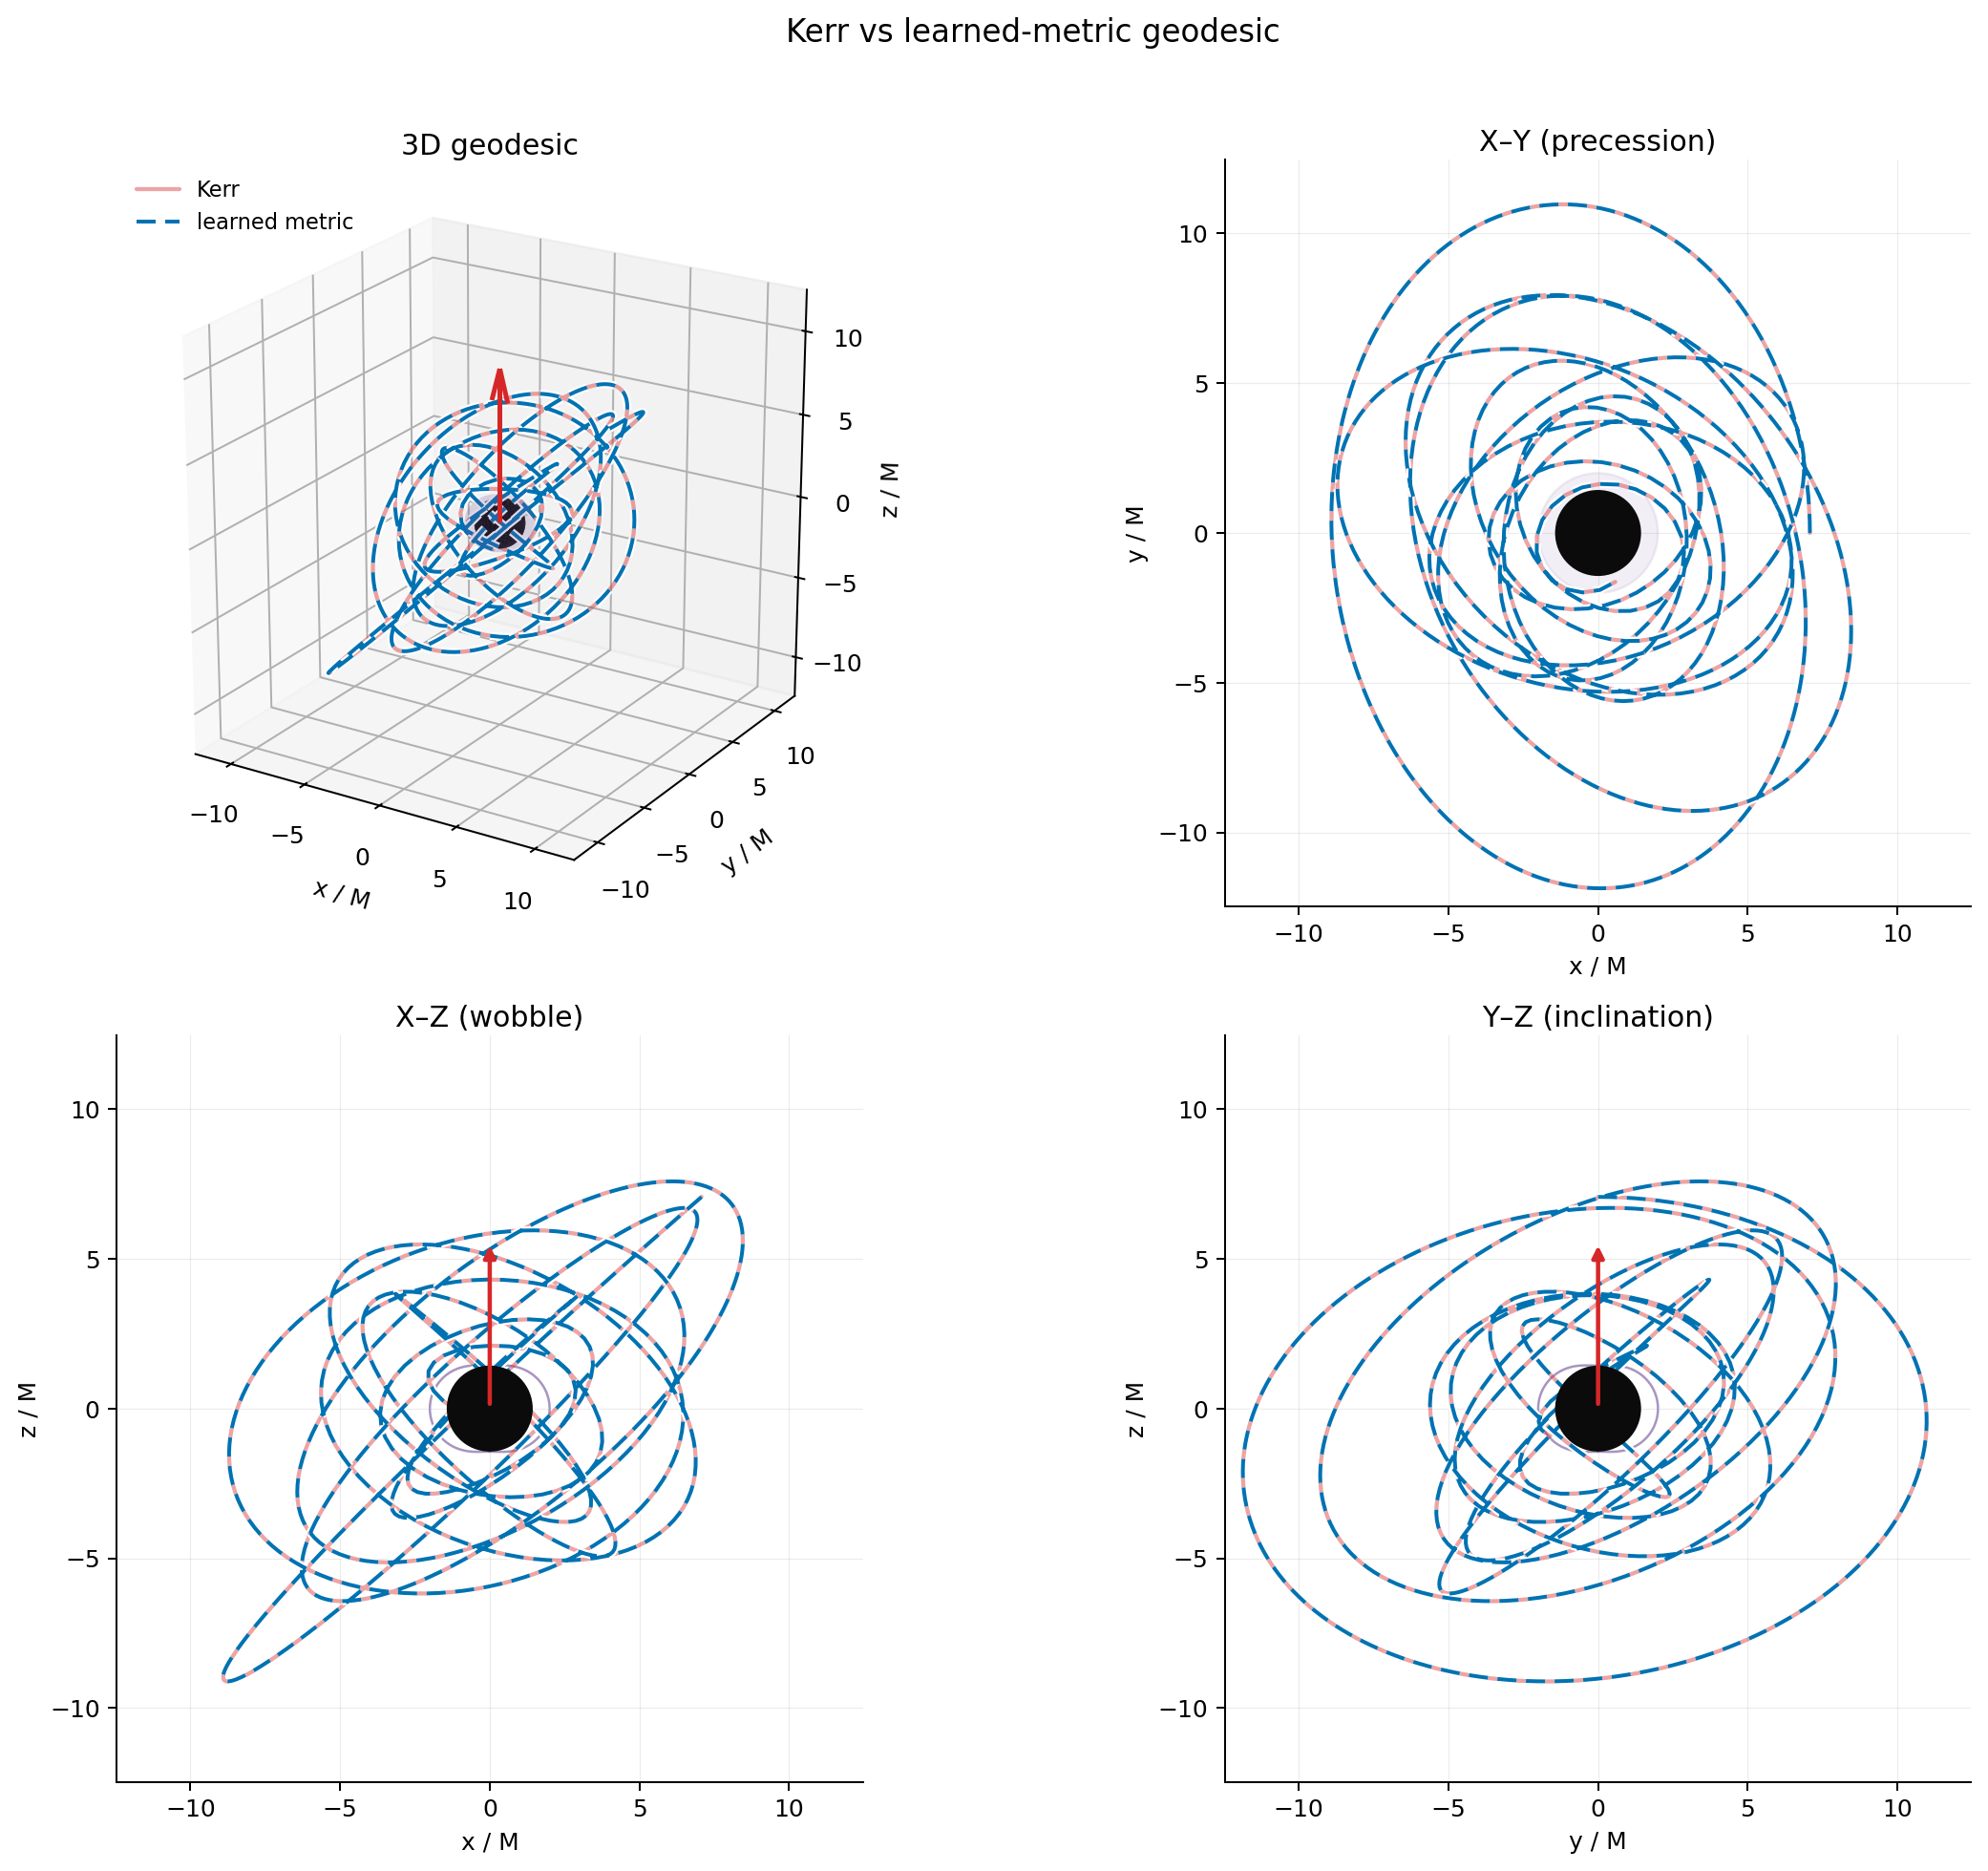

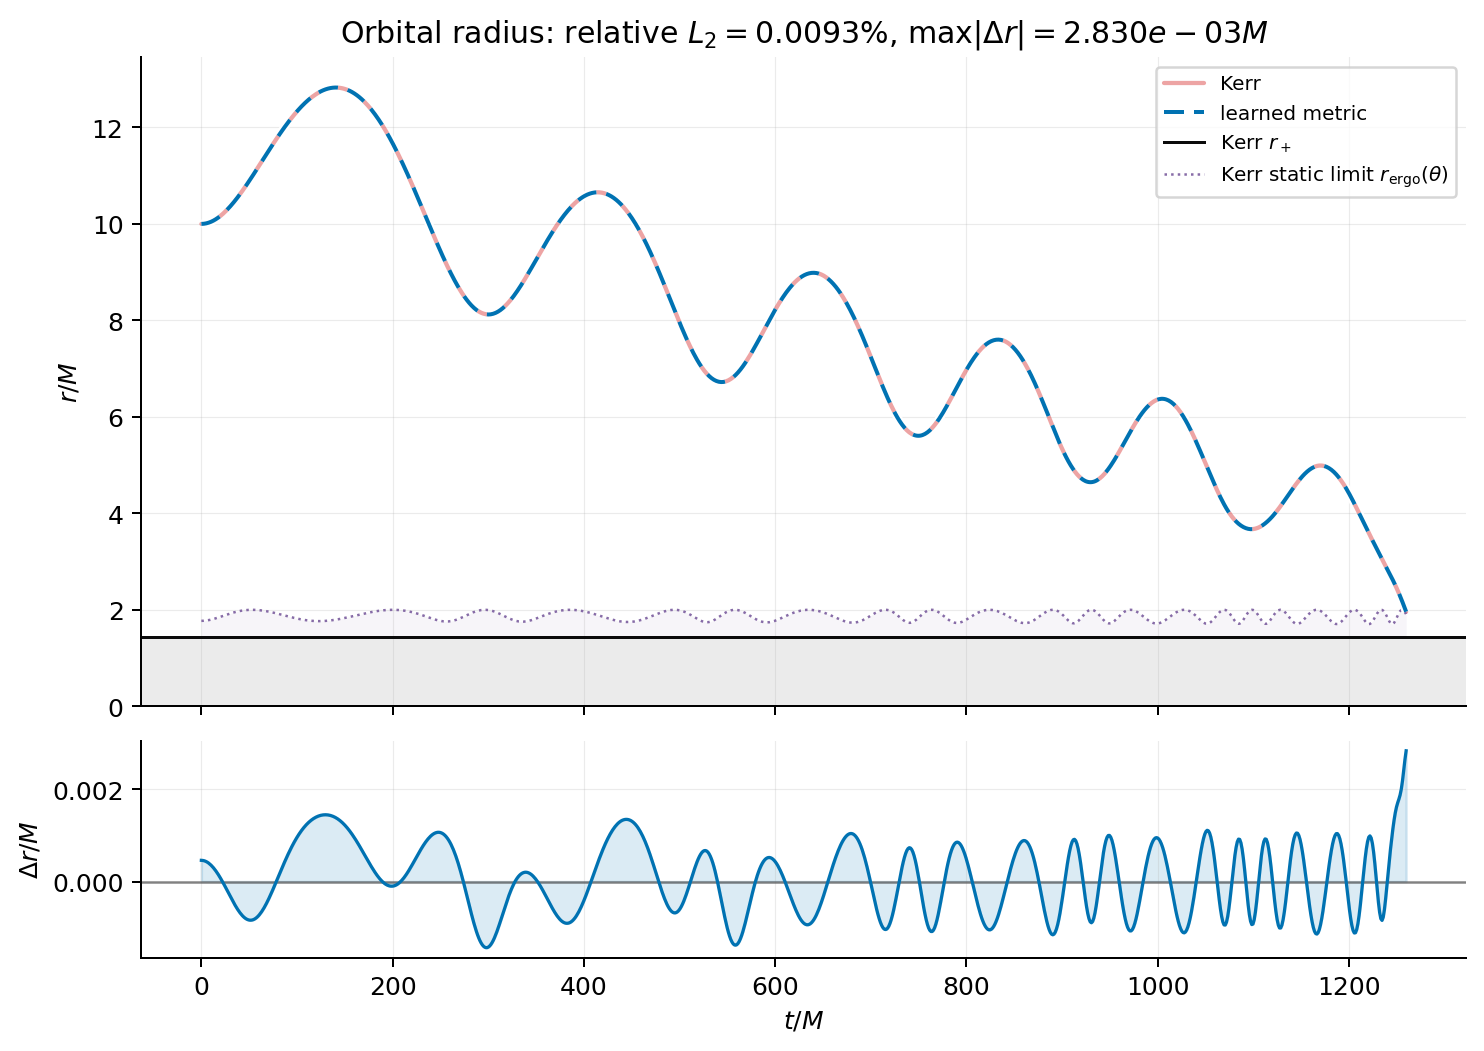

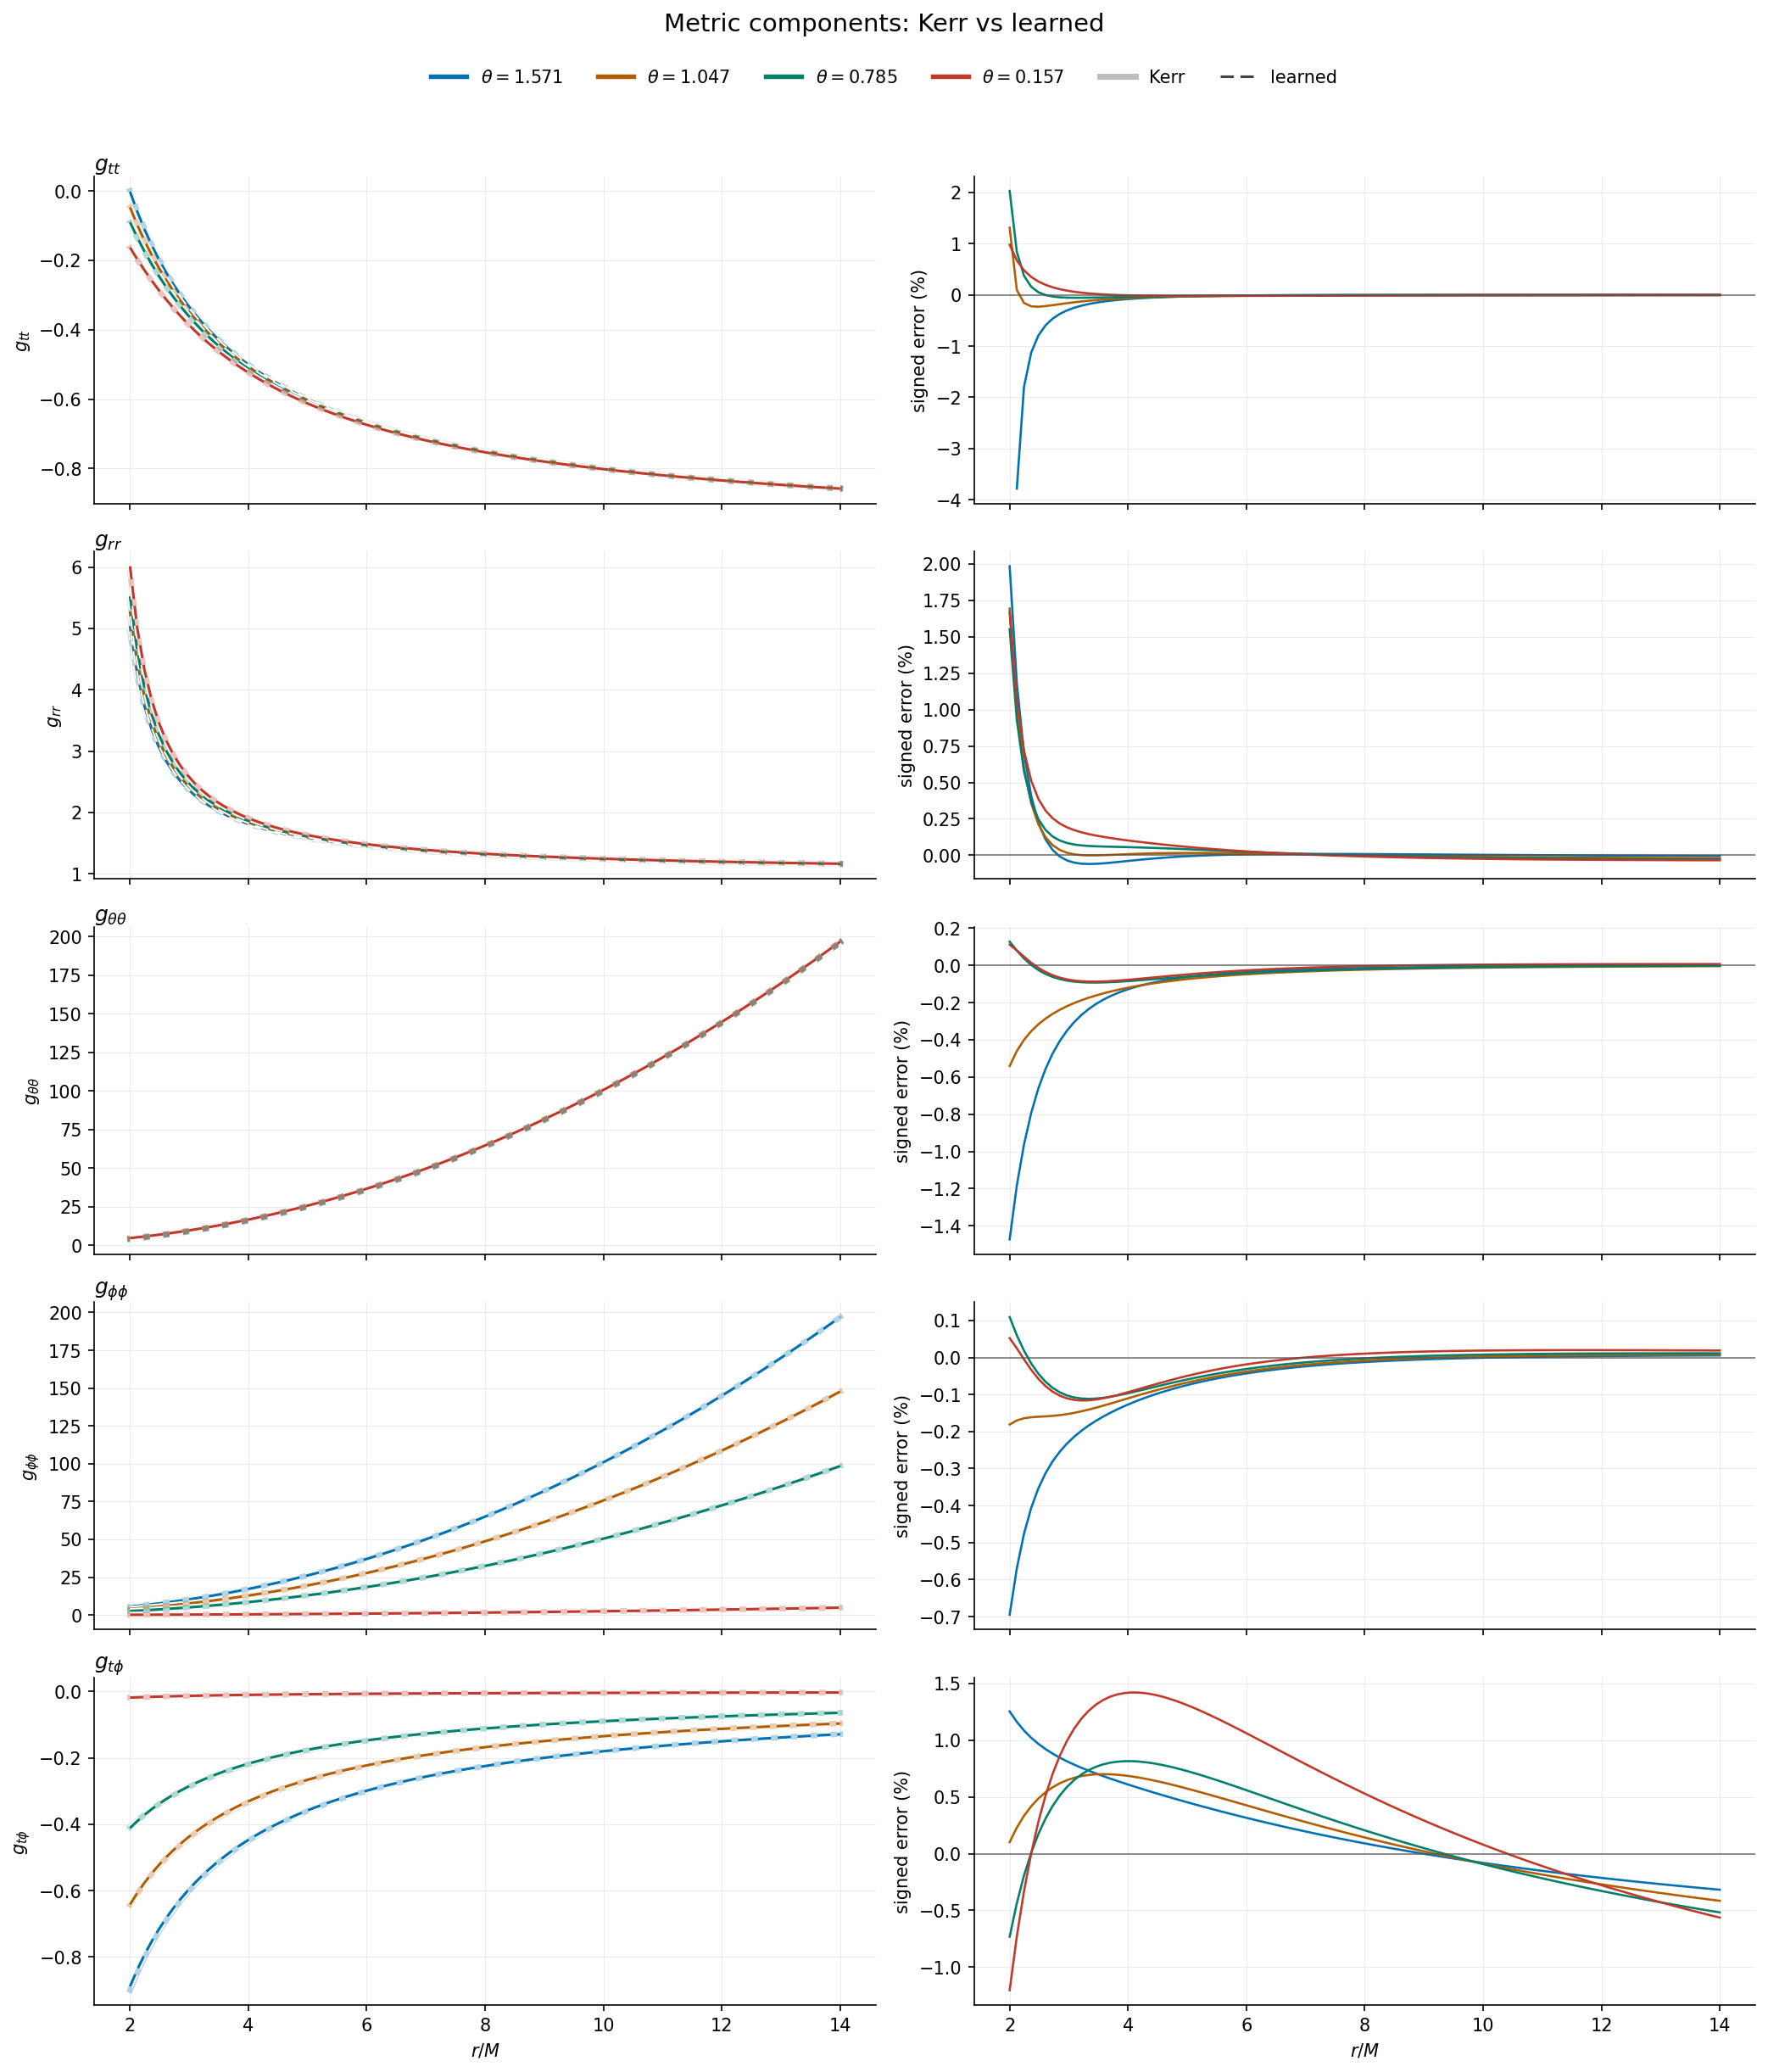

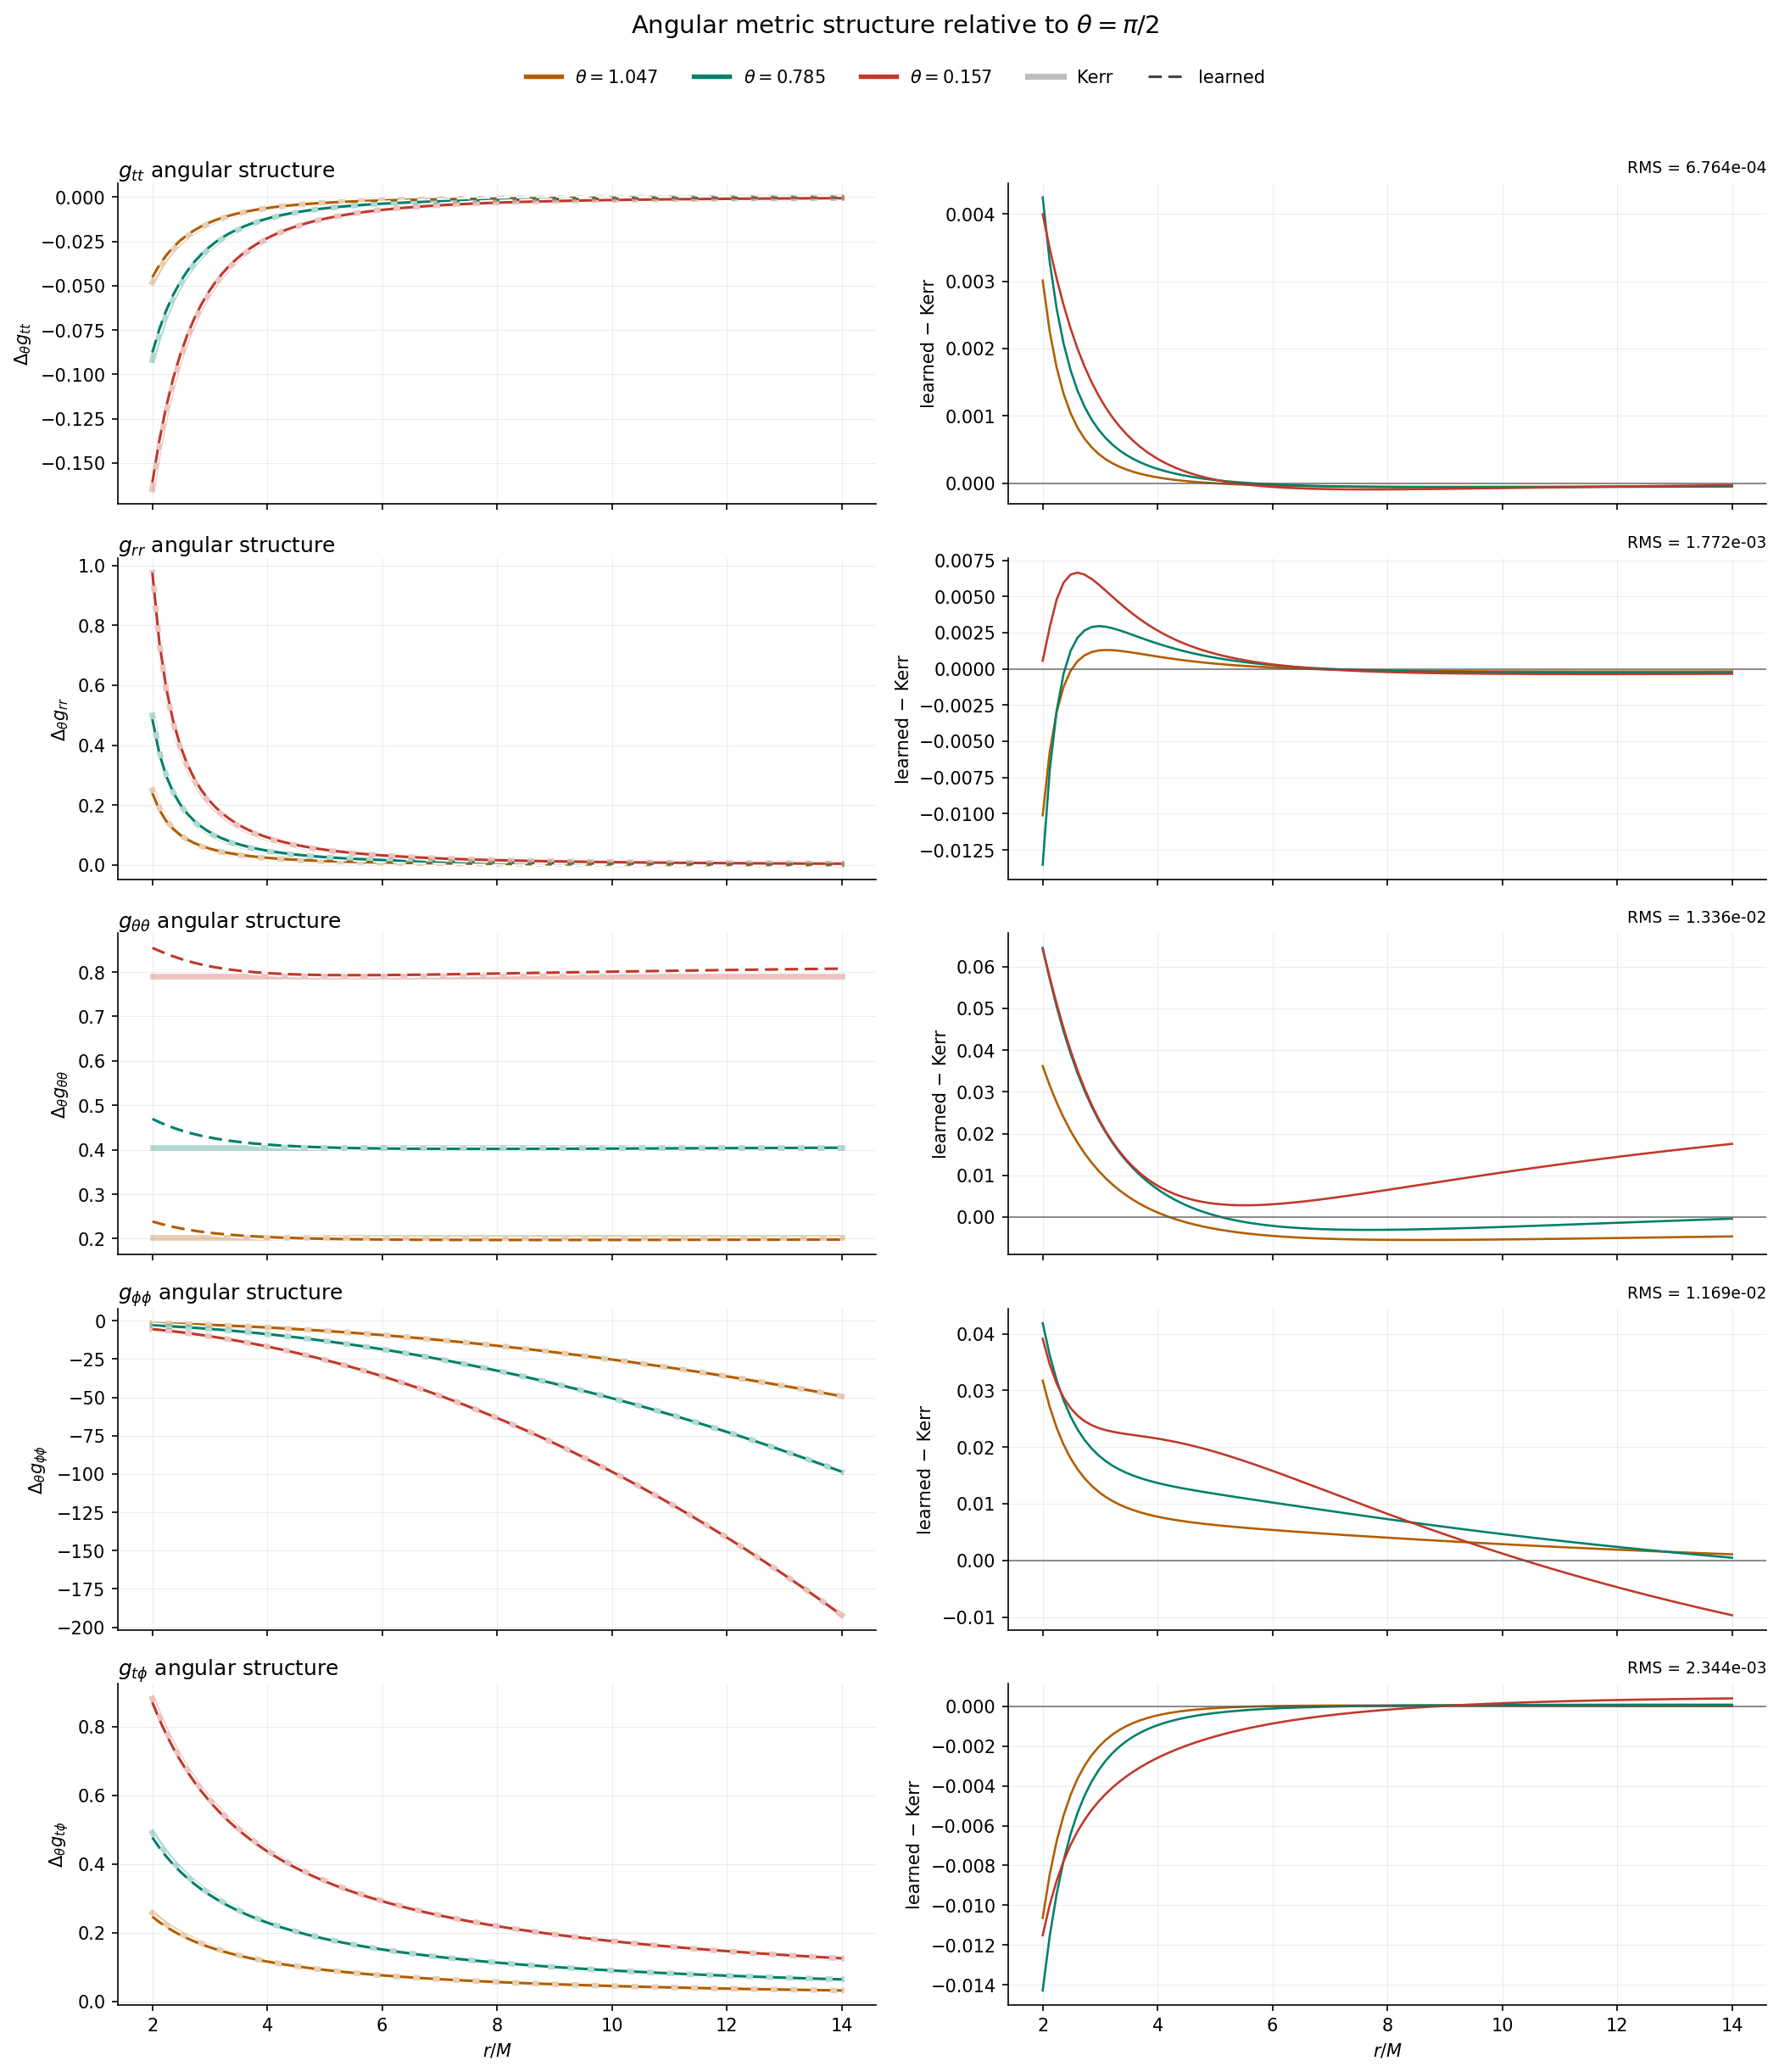

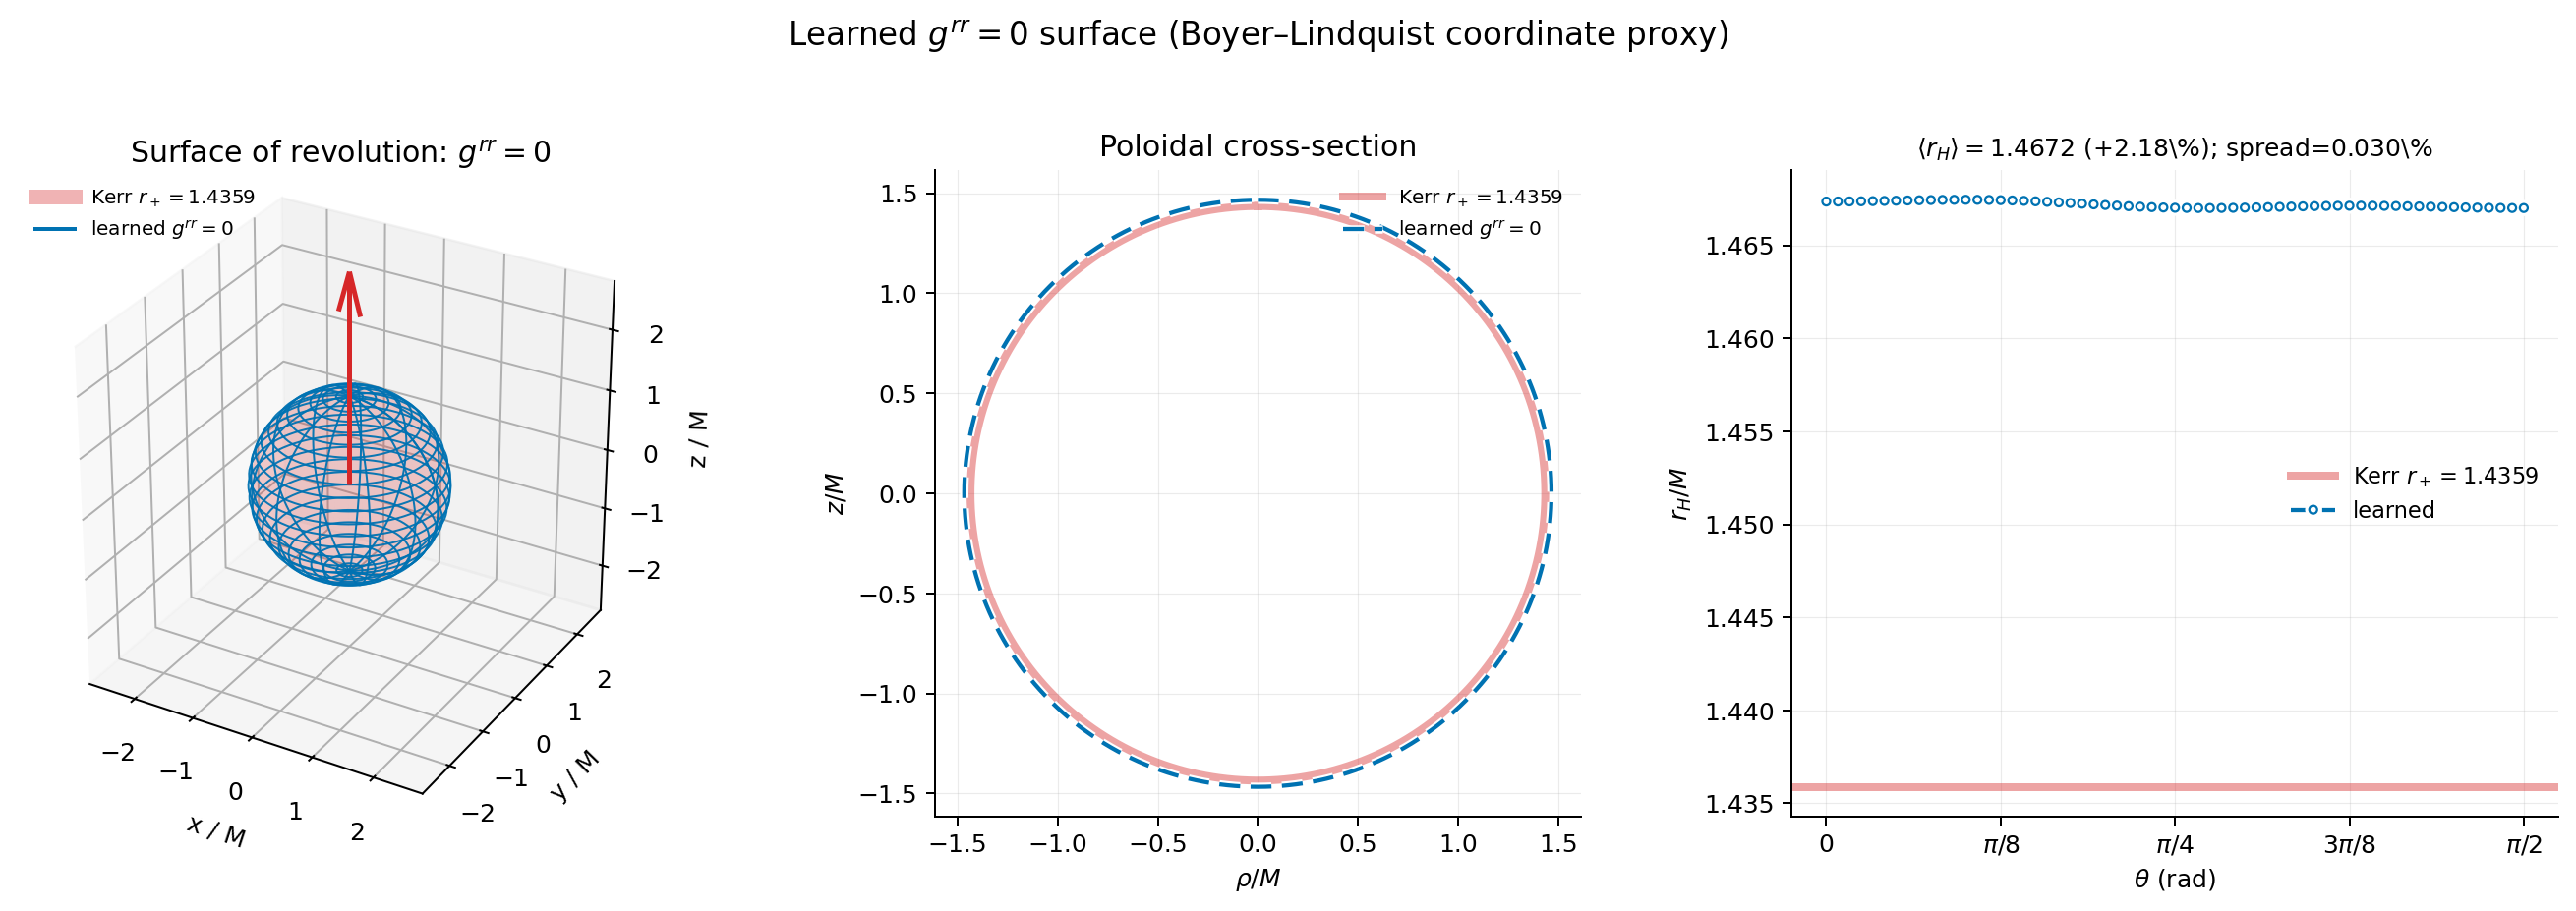

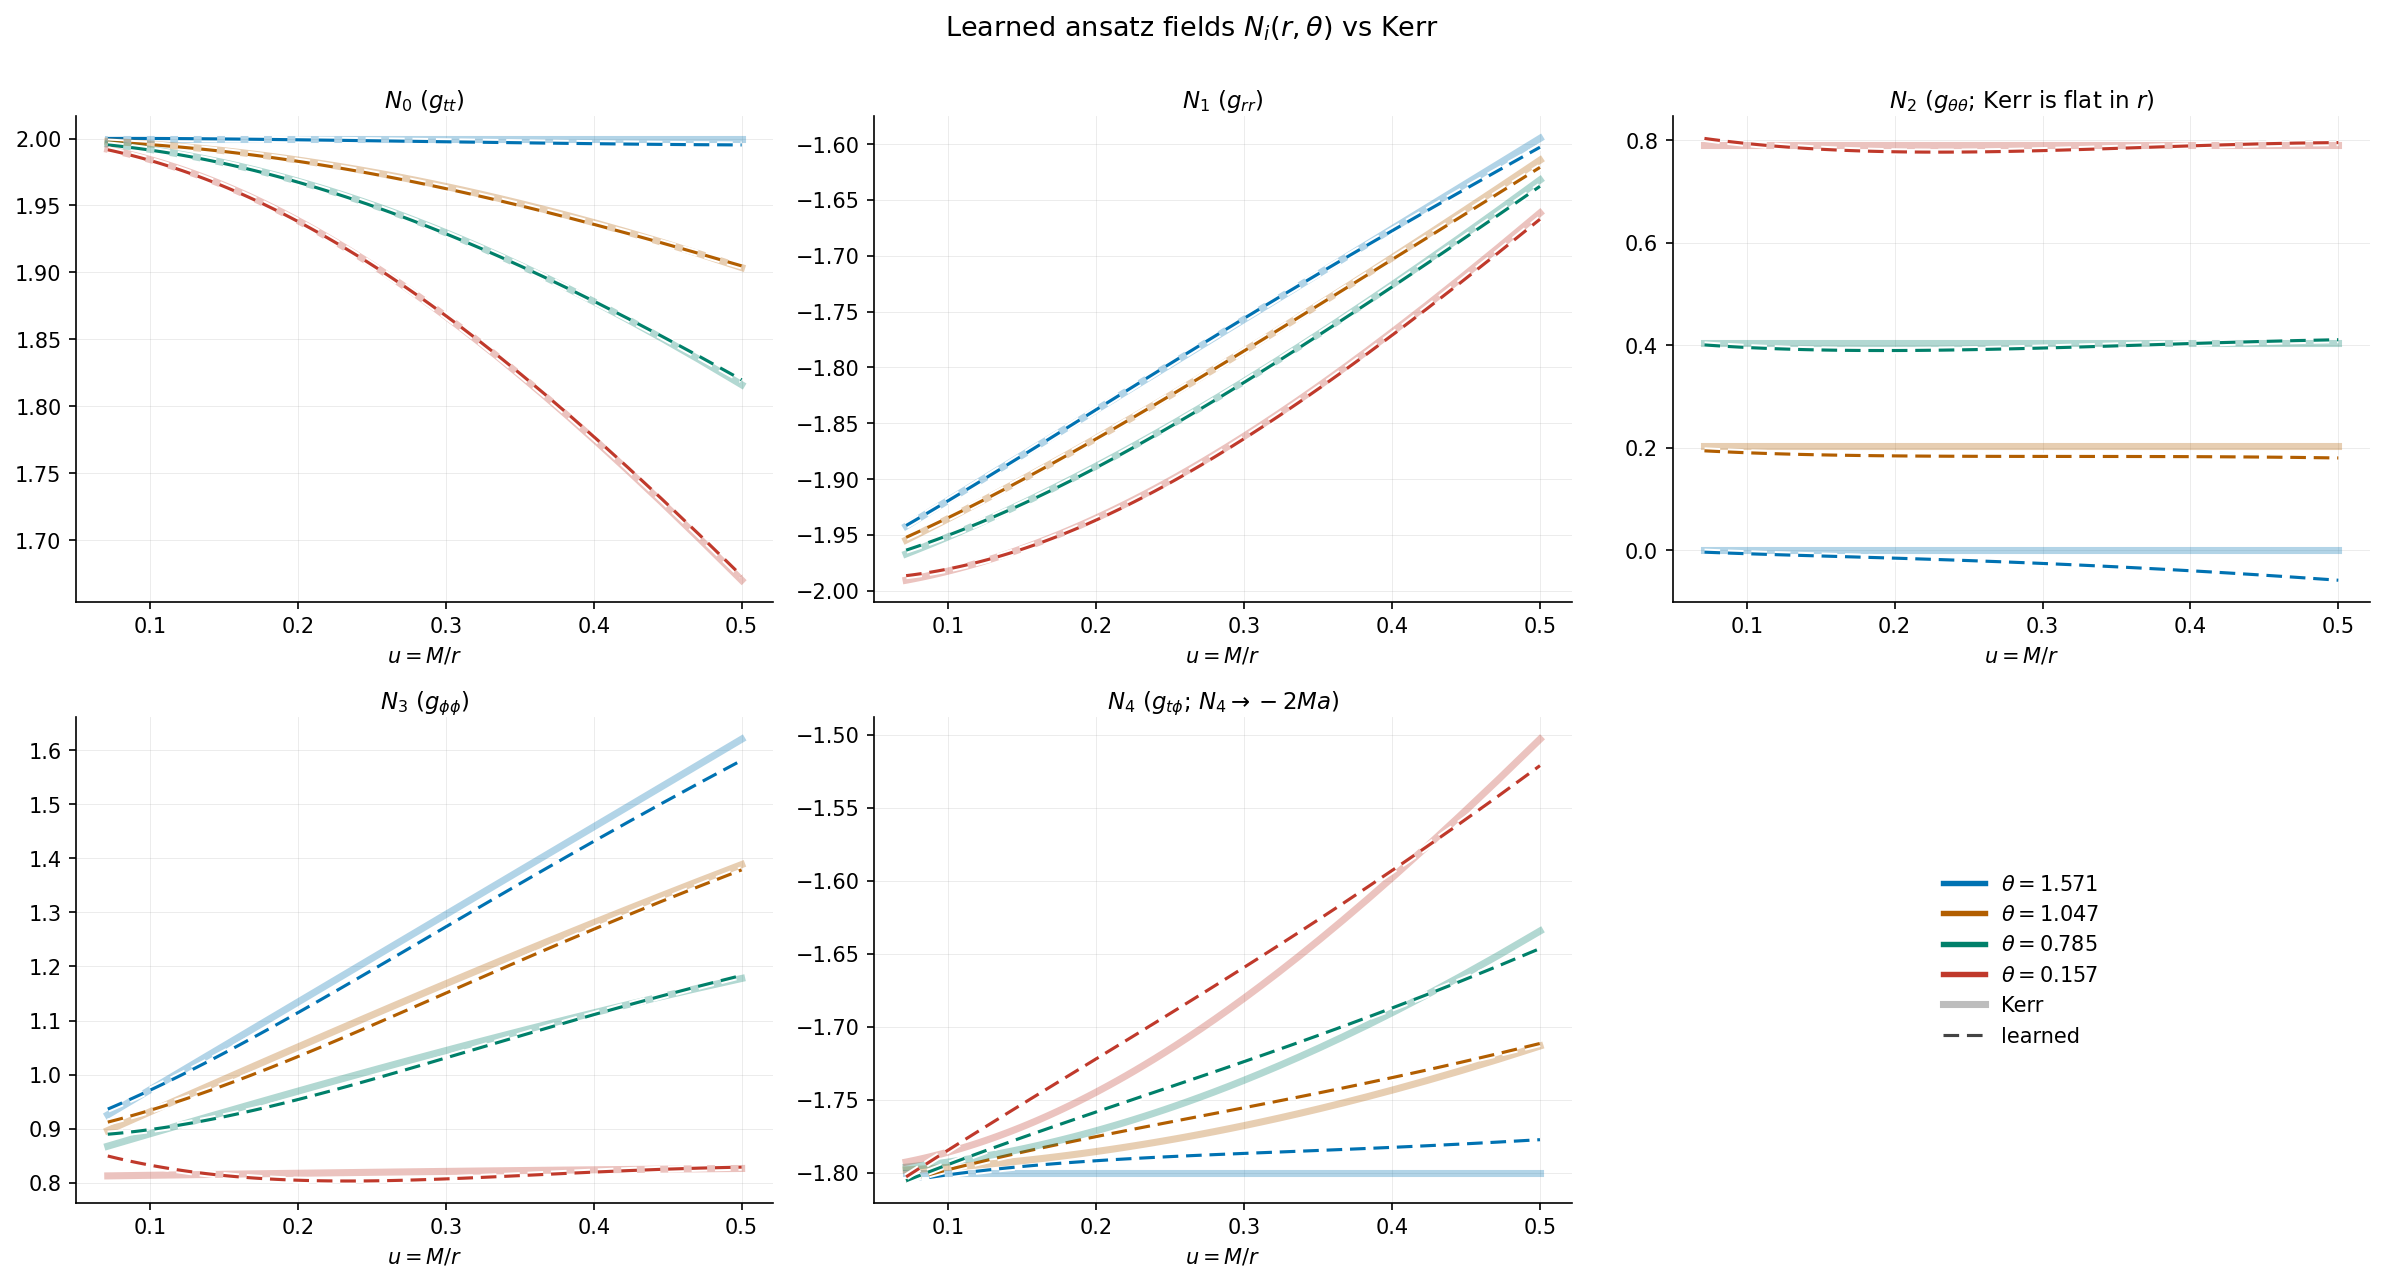

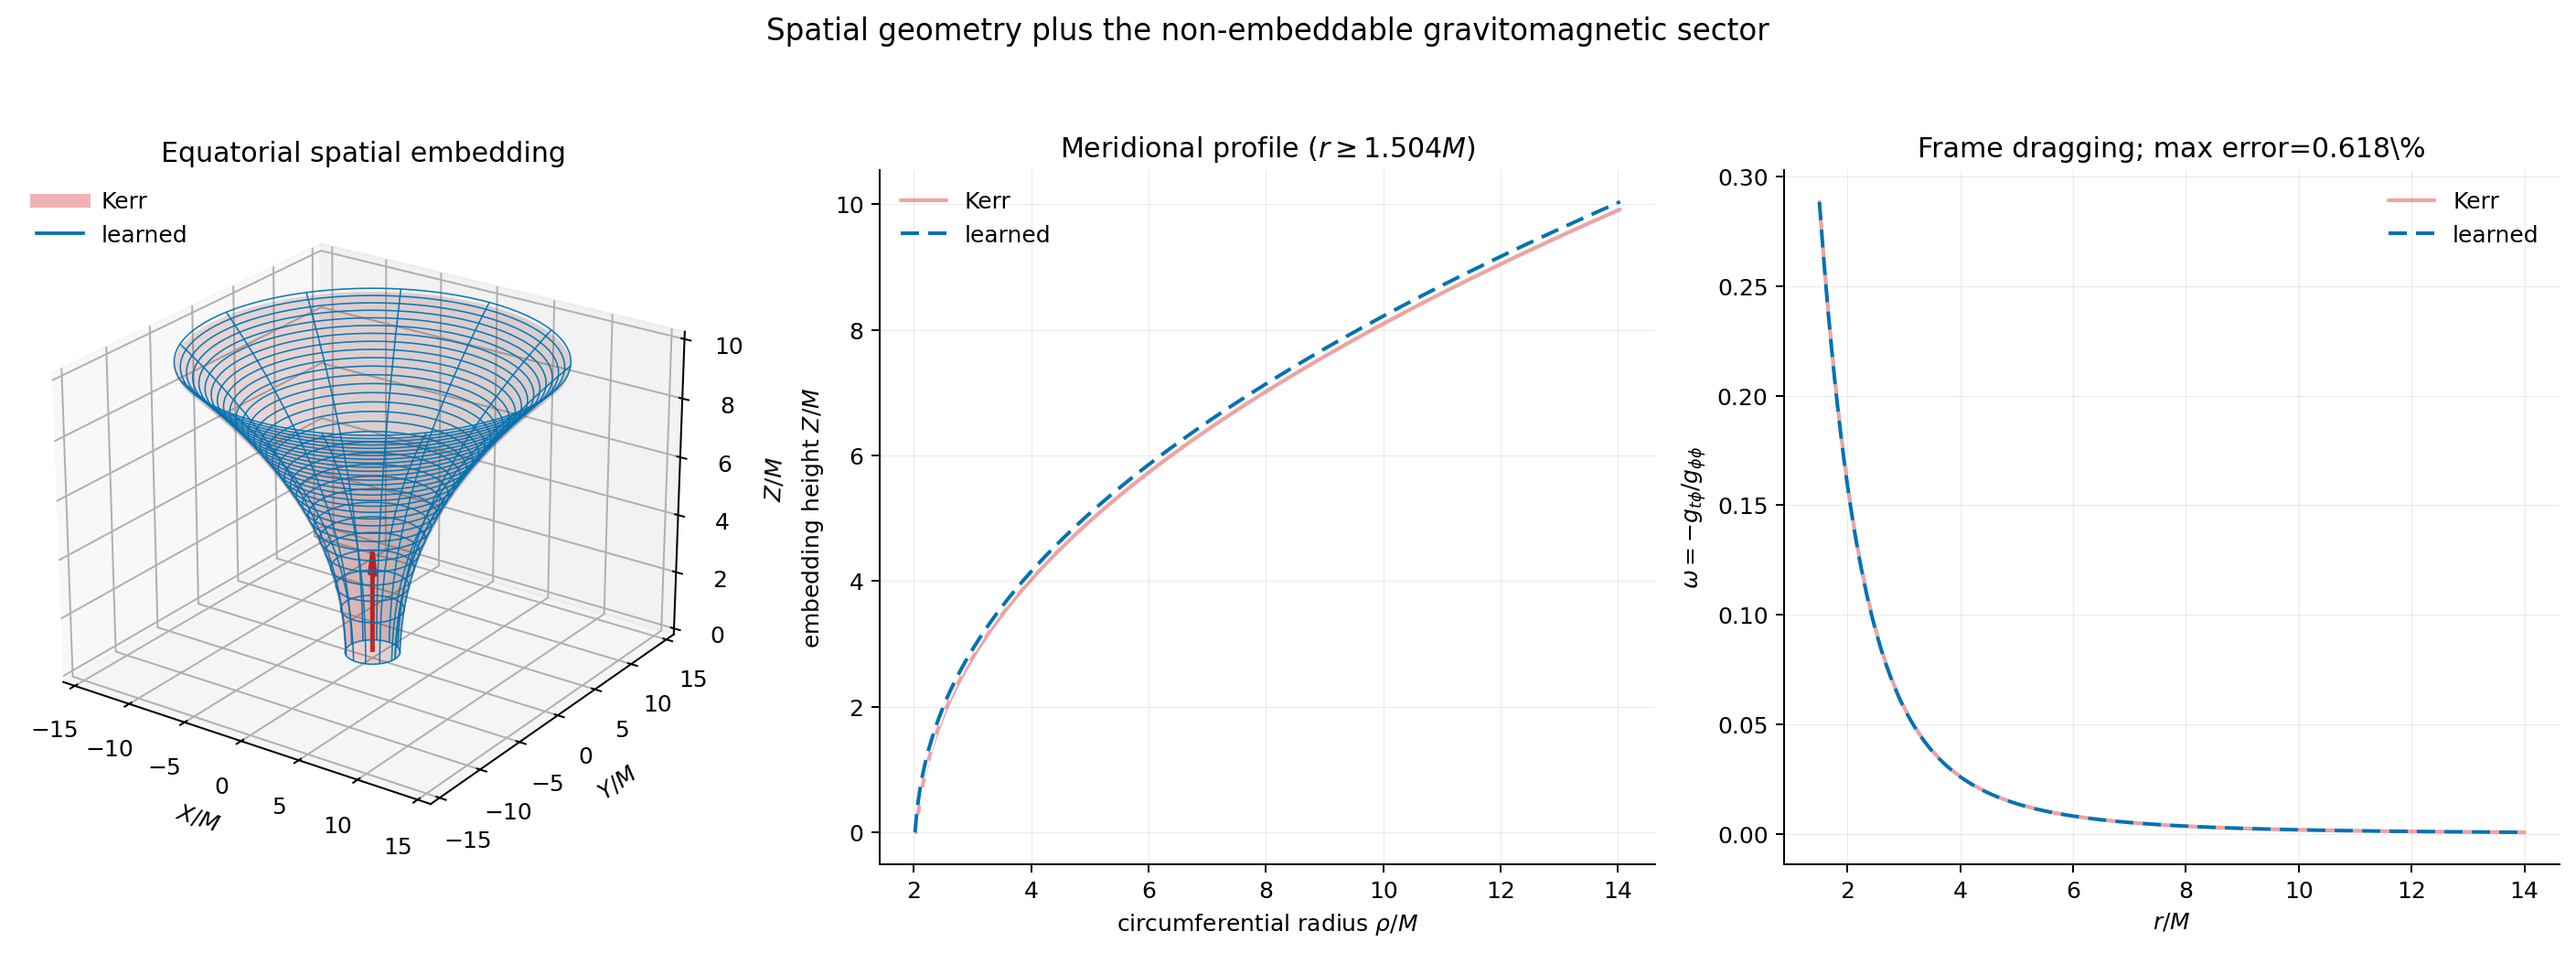

In [54]:
geodesic_figure = plotGeodesicProjections(
    trajectory_gate, trajectory, a_true, show_ergo=True
)
radius_figure, radius_data = plot_radius_overlay(
    t_full, trajectory_gate, trajectory
)
metric_profile_figure, metric_profile_data = compare_metrics_v2(params)
angular_metric_figure, angular_metric_data = angular_comparison_metrics_v2(params)
horizon_surface_figure, horizon_theta, horizon_radius = plot_horizon_surface(params)
ansatz_figure, learned_fields, kerr_fields = plot_ansatz_fields(params)
embedding_figure, embedding_data = plot_equatorial_spatial_embedding(params)
plt.show()

In [58]:
# ============================================================
# Metric relative L2 error across theta
# ============================================================

def print_metric_l2_error_table(
    joint,
    radii=(2, 3, 4, 5, 6, 7, 8, 10, 12, 14, 16, 20),
    n_theta=101,
    theta_min=math.pi / 20,
    theta_max=math.pi / 2,
    decimals=2,
):
    """
    For each radius and metric component, compute

        100 * ||g_learned(r,theta) - g_Kerr(r,theta)||_2
              / ||g_Kerr(r,theta)||_2

    where the L2 norm is taken across the sampled theta values.
    """
    metric_params = (
        joint["metric"]
        if isinstance(joint, dict) and "metric" in joint
        else joint
    )
    dtype = metric_params["w1"].dtype

    radius_grid = jnp.asarray(radii, dtype=dtype)
    theta_grid = jnp.linspace(
        theta_min,
        theta_max,
        n_theta,
        dtype=dtype,
    )

    def errors_at_radius(radius):
        learned = jax.vmap(
            lambda theta: metric_from_network(
                metric_params, radius, theta
            )
        )(theta_grid)

        kerr = jax.vmap(
            lambda theta: g_Kerr(radius, theta)
        )(theta_grid)

        def relative_l2(i, j):
            learned_component = learned[:, i, j]
            kerr_component = kerr[:, i, j]

            numerator = jnp.linalg.norm(
                learned_component - kerr_component
            )
            denominator = jnp.linalg.norm(kerr_component)

            return (
                100.0
                * numerator
                / jnp.maximum(denominator, jnp.finfo(dtype).tiny)
            )

        return jnp.stack((
            relative_l2(0, 0),  # g_tt
            relative_l2(1, 1),  # g_rr
            relative_l2(2, 2),  # g_theta theta
            relative_l2(3, 3),  # g_phi phi
            relative_l2(0, 3),  # g_t phi
        ))

    # Shape after vmap: (number of radii, 5 components).
    errors = jax.vmap(errors_at_radius)(radius_grid)
    errors = np.asarray(jax.device_get(errors), dtype=float).T

    component_labels = [
        "g_tt",
        "g_rr",
        "g_θθ",
        "g_ϕϕ",
        "g_tϕ",
    ]
    headers = ["Component"] + [f"r={r:g}" for r in radii]

    formatted_rows = [
        [label] + [
            f"{value:.{decimals}f}"
            for value in component_errors
        ]
        for label, component_errors
        in zip(component_labels, errors)
    ]

    # Determine column widths from headers and values.
    widths = []
    for column in range(len(headers)):
        entries = [headers[column]] + [
            row[column] for row in formatted_rows
        ]
        widths.append(max(len(entry) for entry in entries))

    def format_row(values):
        return "|" + "|".join(
            f" {value:^{width}} "
            for value, width in zip(values, widths)
        ) + "|"

    separator = "+" + "+".join(
        "-" * (width + 2) for width in widths
    ) + "+"

    title = "Metric Relative L2 Error Across θ (%)"
    outer_border = "+" + "-" * (len(separator) - 2) + "+"

    print(outer_border)
    print("|" + title.center(len(separator) - 2) + "|")
    print(separator)
    print(format_row(headers))
    print(separator)

    for row in formatted_rows:
        print(format_row(row))

    print(separator)

    return {
        "errors_percent": errors,
        "radii": np.asarray(radii, dtype=float),
        "theta": np.asarray(jax.device_get(theta_grid)),
        "components": component_labels,
    }


metric_l2_table = print_metric_l2_error_table(params)

+-----------------------------------------------------------------------------------------------+
|                             Metric Relative L2 Error Across θ (%)                             |
+-----------+------+------+------+------+------+------+------+------+------+------+------+------+
| Component | r=2  | r=3  | r=4  | r=5  | r=6  | r=7  | r=8  | r=10 | r=12 | r=14 | r=16 | r=20 |
+-----------+------+------+------+------+------+------+------+------+------+------+------+------+
|   g_tt    | 1.74 | 0.15 | 0.05 | 0.03 | 0.01 | 0.01 | 0.01 | 0.01 | 0.00 | 0.00 | 0.00 | 0.00 |
|   g_rr    | 1.70 | 0.11 | 0.07 | 0.04 | 0.02 | 0.01 | 0.00 | 0.01 | 0.02 | 0.02 | 0.03 | 0.03 |
|   g_θθ    | 0.70 | 0.19 | 0.10 | 0.06 | 0.04 | 0.02 | 0.02 | 0.01 | 0.01 | 0.00 | 0.00 | 0.00 |
|   g_ϕϕ    | 0.49 | 0.19 | 0.12 | 0.07 | 0.04 | 0.02 | 0.01 | 0.00 | 0.01 | 0.01 | 0.01 | 0.01 |
|   g_tϕ    | 0.90 | 0.73 | 0.68 | 0.55 | 0.41 | 0.27 | 0.14 | 0.08 | 0.25 | 0.39 | 0.50 | 0.66 |
+-----------+------+

In [60]:
# ============================================================
# Initial-condition recovery: truth, initial guess, prediction
# ============================================================

def print_initial_condition_error_table(
    joint,
    true_u0,
    initial_guess=(9.0, 0.90, -0.90, 2.30),
    value_decimals=8,
    error_decimals=4,
    perturbation_decimals=2,
):
    """
    initial_guess follows encode_ic(r, theta, pt, Lz).

    The displayed physical quantities are:
        E_0     = -p_t
        L_z,0   =  p_phi
        r_0     =  r
        theta_0 =  theta
    """
    if not isinstance(joint, dict) or "ic" not in joint:
        raise ValueError(
            "This checkpoint does not contain learned initial conditions."
        )

    true_u0 = np.asarray(
        jax.device_get(true_u0),
        dtype=float,
    )
    predicted_u0 = np.asarray(
        jax.device_get(decode_ic(joint["ic"])),
        dtype=float,
    )

    # Initial arguments supplied to encode_ic(r, theta, pt, Lz).
    r_guess, theta_guess, pt_guess, Lz_guess = initial_guess

    labels = [
        "E_0",
        "L_z,0",
        "r_0",
        "θ_0",
    ]

    true_values = np.asarray([
        -true_u0[4],       # E_0 = -p_t
         true_u0[7],       # L_z,0 = p_phi
         true_u0[1],       # r_0
         true_u0[2],       # theta_0
    ])

    initial_values = np.asarray([
        -pt_guess,         # E_0 = -(-0.90) = +0.90
         Lz_guess,
         r_guess,
         theta_guess,
    ])

    predicted_values = np.asarray([
        -predicted_u0[4],
         predicted_u0[7],
         predicted_u0[1],
         predicted_u0[2],
    ])

    initial_perturbations = (
        100.0
        * np.abs(initial_values - true_values)
        / np.maximum(np.abs(true_values), 1e-300)
    )

    prediction_errors = (
        100.0
        * np.abs(predicted_values - true_values)
        / np.maximum(np.abs(true_values), 1e-300)
    )

    headers = [
        "Parameter",
        "True",
        "Initial Guess (perturbation)",
        "Predicted",
        "Error (%)",
    ]

    rows = []
    for label, true, initial, perturbation, predicted, error in zip(
        labels,
        true_values,
        initial_values,
        initial_perturbations,
        predicted_values,
        prediction_errors,
    ):
        rows.append([
            label,
            f"{true:.{value_decimals}f}",
            (
                f"{initial:.{value_decimals}f} "
                f"({perturbation:.{perturbation_decimals}f}%)"
            ),
            f"{predicted:.{value_decimals}f}",
            f"{error:.{error_decimals}f}",
        ])

    widths = [
        max(len(headers[column]), *(len(row[column]) for row in rows))
        for column in range(len(headers))
    ]

    def format_row(values):
        return "|" + "|".join(
            f" {value:^{width}} "
            for value, width in zip(values, widths)
        ) + "|"

    separator = "+" + "+".join(
        "-" * (width + 2) for width in widths
    ) + "+"

    title = "Initial-Condition Recovery"
    outer_border = "+" + "-" * (len(separator) - 2) + "+"

    print(outer_border)
    print("|" + title.center(len(separator) - 2) + "|")
    print(separator)
    print(format_row(headers))
    print(separator)

    for row in rows:
        print(format_row(row))

    print(separator)

    return {
        "labels": labels,
        "true": true_values,
        "initial_guess": initial_values,
        "initial_perturbation_percent": initial_perturbations,
        "predicted": predicted_values,
        "prediction_error_percent": prediction_errors,
        "true_u0": true_u0,
        "predicted_u0": predicted_u0,
    }


initial_condition_table = print_initial_condition_error_table(
    params,
    U0,
    initial_guess=(9.0, 0.90, -0.90, 2.30),
)

+----------------------------------------------------------------------------------+
|                            Initial-Condition Recovery                            |
+-----------+-------------+------------------------------+-------------+-----------+
| Parameter |    True     | Initial Guess (perturbation) |  Predicted  | Error (%) |
+-----------+-------------+------------------------------+-------------+-----------+
|    E_0    | 0.96048519  |      0.90000000 (6.30%)      | 0.96050442  |  0.0020   |
|   L_z,0   | 2.66185247  |     2.30000000 (13.59%)      | 2.66272969  |  0.0330   |
|    r_0    | 10.00000000 |     9.00000000 (10.00%)      | 10.00045842 |  0.0046   |
|    θ_0    | 0.78539816  |     0.90000000 (14.59%)      | 0.78583236  |  0.0553   |
+-----------+-------------+------------------------------+-------------+-----------+
